# XPURL: Explainable & Continually Adaptive Phishing URL Detection



## Stage 1 — Install & Imports

In [1]:
!pip install -q "shap>=0.46.0" "transformers>=4.41.0,<5.0.0" \
               scikit-learn imbalanced-learn tldextract requests datasets

import warnings; warnings.filterwarnings('ignore')
import numpy as np, shap
print(f'NumPy: {np.__version__} | SHAP: {shap.__version__}')
print('✅ Ready.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.8 MB/s eta 0:00:00
NumPy: 2.0.2 | SHAP: 0.51.0
✅ Ready.


In [2]:
import os, re, math, time, random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from urllib.parse import urlparse

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.amp import GradScaler, autocast

from transformers import DistilBertTokenizerFast, DistilBertModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
import tldextract

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = {
    'max_char_len'   : 64,
    'stat_feat_dim'  : 25,
    'bert_hidden'    : 768,
    'fusion_dim'     : 256,
    'dropout'        : 0.3,
    'batch_size'     : 128,
    'epochs'         : 9,        # FIX: extended from 6
    'ewc_epochs'     : 3,
    'lr'             : 3e-5,
    'ewc_lambda'     : 500000,   # FIX: was 5000 — must be large to overcome tiny Fisher values
    'num_classes'    : 2,
    'max_samples'    : 20000,
    'use_amp'        : torch.cuda.is_available(),
}

print(f'Device : {DEVICE}')
print(f'AMP    : {CFG["use_amp"]}')
print(f'Config : {CFG}')

Device : cuda
AMP    : True
Config : {'max_char_len': 64, 'stat_feat_dim': 25, 'bert_hidden': 768, 'fusion_dim': 256, 'dropout': 0.3, 'batch_size': 128, 'epochs': 9, 'ewc_epochs': 3, 'lr': 3e-05, 'ewc_lambda': 500000, 'num_classes': 2, 'max_samples': 20000, 'use_amp': True}


## Stage 2 — Data Loading

In [26]:
import requests, zipfile, io

def load_iscx_phishing_only():
    """ISCX — phishing URLs only (benign excluded: simple domain strings)."""
    try:
        df = pd.read_csv(
            'https://raw.githubusercontent.com/faizann24/Using-machine-learning-to-detect-malicious-URLs/master/data/data.csv',
            on_bad_lines='skip'
        )
        df = df[['url','label']].dropna()
        df['label'] = df['label'].map({'bad':1,'good':0})
        df = df.dropna(subset=['label'])
        df['label'] = df['label'].astype(int)
        df_phish = df[df['label'] == 1].copy()
        print(f'  ISCX phishing only: {len(df_phish):,} rows')
        return df_phish
    except Exception as e:
        print(f'  ISCX failed: {e}'); return None


def load_phishtank():
    """PhishTank verified phishing feed."""
    try:
        r = requests.get('http://data.phishtank.com/data/online-valid.json',
                         timeout=30, headers={'User-Agent':'phishing-research-bot/1.0'})
        r.raise_for_status()
        entries = r.json()
        urls = [e['url'] for e in entries if e.get('verified') == 'yes']
        df = pd.DataFrame({'url': urls[:5000], 'label': 1})
        print(f'  PhishTank: {len(df):,} rows'); return df
    except Exception as e:
        print(f'  PhishTank failed: {e}'); return None


def load_phiusiil(max_phish=10000, max_benign=30000):
    """
    PhiUSIIL dataset (Prasad & Chandra, 2024 — Computers & Security).
    235,795 URLs: 100,945 phishing + 134,850 legitimate.
    Loaded via ucimlrepo (id=967).
    NOTE: PhiUSIIL label convention is REVERSED — 1=legitimate, 0=phishing.
    """
    try:
        from ucimlrepo import fetch_ucirepo
        print('  Fetching PhiUSIIL from UCI (id=967)...')
        ds = fetch_ucirepo(id=967)
        X  = ds.data.features
        y  = ds.data.targets

        url_col = [c for c in X.columns if c.upper() == 'URL']
        if not url_col:
            raise ValueError(f'No URL column found. Columns: {X.columns.tolist()}')
        url_col = url_col[0]

        df = pd.DataFrame({'url': X[url_col].values, 'label': y.values.flatten()})
        df = df.dropna(subset=['url','label'])
        df['url']   = df['url'].astype(str).str.strip()
        df['label'] = df['label'].astype(int)

        # Re-map: PhiUSIIL 1=legit→0, 0=phish→1
        df['label'] = df['label'].map({1: 0, 0: 1})

        df_phish  = df[df['label'] == 1].sample(
            n=min(max_phish,  (df['label']==1).sum()), random_state=SEED)
        df_benign = df[df['label'] == 0].sample(
            n=min(max_benign, (df['label']==0).sum()), random_state=SEED)
        df_out = pd.concat([df_phish, df_benign], ignore_index=True)

        print(f'  PhiUSIIL: {len(df_phish):,} phishing + {len(df_benign):,} benign '
              f'({len(df_out):,} total)')
        return df_out

    except ImportError:
        import subprocess, sys
        print('  Installing ucimlrepo...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ucimlrepo'])
        return load_phiusiil(max_phish, max_benign)

    except Exception as e:
        print(f'  PhiUSIIL failed: {e}'); return None


def load_tranco_benign(n=30000):
    """
    Tranco Top-1M — research-grade domain ranking (tranco-list.eu).
    CSV format: rank,domain  (no header row).
    """
    try:
        print('  Downloading Tranco Top-1M...')
        r = requests.get(
            'https://tranco-list.eu/top-1m.csv.zip',
            timeout=60,
            headers={'User-Agent': 'phishing-research-bot/1.0'}
        )
        r.raise_for_status()

        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            fname = z.namelist()[0]
            with z.open(fname) as f:
                tranco = pd.read_csv(f, header=None, names=['rank','domain'],
                                     usecols=['domain'])

        domains = tranco['domain'].dropna().astype(str).str.strip()
        domains = domains[domains.str.len() > 3].head(n * 2)

        url_variants = [
            lambda d: f'https://www.{d}/',
            lambda d: f'https://{d}/',
            lambda d: f'https://www.{d}/about',
            lambda d: f'https://www.{d}/contact',
            lambda d: f'https://www.{d}/news',
            lambda d: f'https://www.{d}/products',
            lambda d: f'https://www.{d}/search?q=info',
            lambda d: f'https://blog.{d}/',
            lambda d: f'https://support.{d}/',
            lambda d: f'https://docs.{d}/',
            lambda d: f'https://www.{d}/login',
            lambda d: f'https://account.{d}/',
            lambda d: f'https://www.{d}/account/settings',
            lambda d: f'https://www.{d}/faq',
            lambda d: f'https://www.{d}/pricing',
        ]

        rng = random.Random(SEED)
        urls = [rng.choice(url_variants)(d) for d in domains]
        df = pd.DataFrame({'url': urls[:n*2], 'label': 0})
        df = df.drop_duplicates(subset='url').head(n)

        print(f'  Tranco benign: {len(df):,} URLs')
        return df

    except Exception as e:
        print(f'  Tranco failed: {e}'); return None


def load_majestic_benign(n=30000):
    """
    Majestic Million — backlink-based top domain ranking.
    CSV columns: GlobalRank, TldRank, Domain, TLD, RefSubNets, RefIPs, ...
    Direct download, no auth required.
    """
    try:
        print('  Downloading Majestic Million...')
        r = requests.get(
            'https://downloads.majestic.com/majestic_million.csv',
            timeout=60,
            headers={'User-Agent': 'phishing-research-bot/1.0'}
        )
        r.raise_for_status()

        df_raw = pd.read_csv(
            io.StringIO(r.text),
            usecols=['Domain', 'TLD'],
            nrows=n * 3
        )
        df_raw = df_raw.dropna(subset=['Domain'])
        df_raw['domain'] = df_raw['Domain'].astype(str).str.strip().str.lower()
        df_raw = df_raw[df_raw['domain'].str.match(r'^[a-z0-9][a-z0-9\.\-]+\.[a-z]{2,}$')]

        url_variants = [
            lambda d: f'https://www.{d}/',
            lambda d: f'https://{d}/',
            lambda d: f'https://www.{d}/about',
            lambda d: f'https://www.{d}/news',
            lambda d: f'https://www.{d}/products',
            lambda d: f'https://www.{d}/services',
            lambda d: f'https://www.{d}/blog',
            lambda d: f'https://www.{d}/contact',
            lambda d: f'https://shop.{d}/',
            lambda d: f'https://support.{d}/',
            lambda d: f'https://www.{d}/login',
            lambda d: f'https://account.{d}/',
            lambda d: f'https://www.{d}/account/settings',
            lambda d: f'https://www.{d}/help',
            lambda d: f'https://www.{d}/terms',
        ]

        rng = random.Random(SEED + 1)
        urls = [rng.choice(url_variants)(d) for d in df_raw['domain']]
        df_out = pd.DataFrame({'url': urls, 'label': 0})
        df_out = df_out.drop_duplicates(subset='url').head(n)

        print(f'  Majestic benign: {len(df_out):,} URLs')
        return df_out

    except Exception as e:
        print(f'  Majestic failed: {e}'); return None


def load_umbrella_benign(n=20000):
    """
    Cisco Umbrella Top-1M — DNS-traffic-based popularity ranking.
    ZIP contains top-1m.csv: rank,domain (no header row).
    """
    try:
        print('  Downloading Cisco Umbrella Top-1M...')
        r = requests.get(
            'https://s3-us-west-1.amazonaws.com/umbrella-static/top-1m.csv.zip',
            timeout=60,
            headers={'User-Agent': 'phishing-research-bot/1.0'}
        )
        r.raise_for_status()

        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            fname = z.namelist()[0]
            with z.open(fname) as f:
                df_raw = pd.read_csv(
                    f, header=None, names=['rank','domain'],
                    usecols=['domain'], nrows=n * 3
                )

        df_raw['domain'] = df_raw['domain'].astype(str).str.strip().str.lower()
        df_raw = df_raw[df_raw['domain'].str.match(r'^[a-z0-9][a-z0-9\.\-]+\.[a-z]{2,}$')]
        df_raw = df_raw[~df_raw['domain'].str.startswith('www.')]

        url_variants = [
            lambda d: f'https://www.{d}/',
            lambda d: f'https://{d}/',
            lambda d: f'https://www.{d}/home',
            lambda d: f'https://www.{d}/about',
            lambda d: f'https://www.{d}/search?q=help',
            lambda d: f'https://www.{d}/faq',
            lambda d: f'https://www.{d}/login',
            lambda d: f'https://account.{d}/',
            lambda d: f'https://api.{d}/v1/status',
            lambda d: f'https://cdn.{d}/assets/main.js',
            lambda d: f'https://www.{d}/privacy',
            lambda d: f'https://www.{d}/careers',
            lambda d: f'https://www.{d}/press',
            lambda d: f'https://www.{d}/downloads',
            lambda d: f'https://www.{d}/support',
        ]

        rng = random.Random(SEED + 2)
        urls = [rng.choice(url_variants)(d) for d in df_raw['domain']]
        df_out = pd.DataFrame({'url': urls, 'label': 0})
        df_out = df_out.drop_duplicates(subset='url').head(n)

        print(f'  Umbrella benign: {len(df_out):,} URLs')
        return df_out

    except Exception as e:
        print(f'  Umbrella failed: {e}'); return None


def generate_realistic_dataset(n_phish=5000, n_benign=5000):
    """
    Synthetic URLs — fills gaps and adds edge-case variety.
    Benign includes security keywords; phishing uses mixed TLDs.
    """
    print('  Generating realistic dataset...')

    benign_domains = [
        'google','amazon','microsoft','apple','wikipedia','github','youtube',
        'reddit','twitter','facebook','linkedin','netflix','adobe','dropbox',
        'slack','zoom','stripe','shopify','medium','cloudflare','notion',
        'python','django','stackoverflow','pytorch','tensorflow','huggingface',
        'bbc','nytimes','reuters','bloomberg','forbes','techcrunch','wired',
        'spotify','twitch','discord','figma','vercel','heroku','digitalocean'
    ]
    benign_templates = [
        'https://www.{d}.com',
        'https://{d}.com',
        'https://www.{d}.org',
        'https://{d}.io',
        'https://www.{d}.net',
        'https://{d}.co.uk',
        'https://www.{d}.edu',
        'https://www.{d}.com/{w}',
        'https://{d}.com/about',
        'https://{d}.com/contact',
        'https://www.{d}.com/pricing',
        'https://www.{d}.com/features',
        'https://www.{d}.com/search?q={w}+tutorial&page={n}',
        'https://www.{d}.com/results?query={w}&sort=relevance',
        'https://www.{d}.com/products/{w}/details',
        'https://www.{d}.com/blog/{y}/{m}/{w}-guide',
        'https://shop.{d}.com/category/{w}?page={n}',
        'https://docs.{d}.com/en/{w}/getting-started',
        'https://docs.{d}.io/guides/{w}/installation',
        'https://{d}.com/docs/v{n}/api/reference',
        'https://developer.{d}.com/docs/{w}/overview',
        'https://api.{d}.com/v{n}/users/{w}?format=json',
        'https://www.{d}.org/wiki/{w}',
        'https://learn.{d}.com/courses/{n}/{w}/module-{n}',
        'https://www.{d}.com/news/{y}/{m}/{n}/{w}.html',
        'https://www.{d}.com/watch?v={tok}',
        'https://accounts.{d}.com/signin',
        'https://secure.{d}.com/login',
        'https://www.{d}.com/account/settings',
        'https://www.{d}.com/account/security',
        'https://login.{d}.com/auth',
        'https://www.{d}.com/verify-email?token={tok}',
        'https://www.{d}.com/password/reset',
        'https://support.{d}.com/confirm-subscription',
        'https://www.{d}.com/banking/overview',
        'https://www.{d}.com/update-profile',
    ]
    content_words = [
        'machine-learning','python','javascript','tutorial','introduction',
        'getting-started','best-practices','advanced-guide','quick-start',
        'installation','configuration','deployment','testing','security',
        'performance','optimization','debugging','overview','reference',
        'release-notes','changelog','faq','support','community'
    ]
    phishing_patterns = [
        'http://paypal-secure-login.{tld}/verify?token={tok}',
        'http://{brand}-account-update.{tld}/signin',
        'https://secure-{brand}.{tld}/suspended/reactivate',
        'http://{tok}.{brand}-login.{tld}/access',
        'http://www.{brand}-verify.{tld}/login.php?id={tok}',
        'https://{brand}.com.{tld}/account/login',
        'http://{ip}/phish/{tok}/login',
        'https://{tok}{tok}.{brand}security.{tld}/',
        'http://secure.{brand}{tok}.info/verify',
        'https://{brand}-support-team.{tld}/case={tok}',
        'http://{brand}.{tld}/cmd=login/id={tok}',
        'https://update-{brand}-password.{tld}/reset',
        'http://www.{brand}-online.{tld}/customer/account/login/',
        'https://{tok}.{tld}/secure/{brand}/signin.php',
        'http://{brand}-alert-notification.{tld}/urgent/verify',
    ]
    brands = ['paypal','apple','amazon','microsoft','netflix','google',
              'chase','wellsfargo','bankofamerica','citibank','usps',
              'fedex','irs','instagram','facebook','ebay','steam']
    sus_tlds    = ['ru','cn','tk','ml','ga','cf','gq','xyz','top','club','pw','cc']
    normal_tlds = ['com','net','org','info']
    months      = ['01','02','03','04','05','06','07','08','09','10','11','12']

    def rand_tok(n=8):
        return ''.join(random.choices('abcdefghijklmnopqrstuvwxyz0123456789', k=n))
    def rand_ip():
        return '.'.join(str(random.randint(1,254)) for _ in range(4))

    benign_urls = []
    for _ in range(n_benign):
        t = random.choice(benign_templates)
        url = t.format(
            d=random.choice(benign_domains),
            w=random.choice(content_words),
            n=random.randint(1, 999),
            y=random.randint(2015, 2024),
            m=random.choice(months),
            tok=rand_tok(random.randint(8, 16))
        )
        benign_urls.append(url)

    phish_urls = []
    for _ in range(n_phish):
        tld = random.choice(normal_tlds) if random.random() < 0.4 \
              else random.choice(sus_tlds)
        url = random.choice(phishing_patterns).format(
            brand=random.choice(brands), tld=tld,
            tok=rand_tok(random.randint(6,14)), ip=rand_ip()
        )
        phish_urls.append(url)

    df = pd.DataFrame({'url': benign_urls + phish_urls,
                       'label': [0]*n_benign + [1]*n_phish})
    print(f'  Realistic synthetic: {n_benign} benign + {n_phish} phishing '
          f'(mixed TLDs, security keywords in benign)')
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)


# ── Assemble ───────────────────────────────────────────────────────────────
print('Loading datasets...')
frames = []

# ── Phishing sources ───────────────────────────────────────────────────────
iscx_phish = load_iscx_phishing_only()
if iscx_phish is not None:
    frames.append(iscx_phish)

pt = load_phishtank()
if pt is not None:
    frames.append(pt)

# PhiUSIIL — 10k phishing + 30k benign (has 134,850 legit available)
phiusiil = load_phiusiil(max_phish=10000, max_benign=30000)
if phiusiil is not None:
    frames.append(phiusiil)

# ── Benign sources ─────────────────────────────────────────────────────────
tranco = load_tranco_benign(n=30000)
if tranco is not None:
    frames.append(tranco)

majestic = load_majestic_benign(n=30000)
if majestic is not None:
    frames.append(majestic)

umbrella = load_umbrella_benign(n=20000)
if umbrella is not None:
    frames.append(umbrella)

# Synthetic — edge-case variety, small contribution
frames.append(generate_realistic_dataset(n_phish=5000, n_benign=5000))

# ── Merge & clean ──────────────────────────────────────────────────────────
df_all = pd.concat(frames, ignore_index=True)
df_all = df_all.dropna(subset=['url','label'])
df_all['url'] = df_all['url'].astype(str).str.strip()
df_all = df_all[df_all['url'].str.len() > 8]
df_all = df_all.drop_duplicates(subset='url').reset_index(drop=True)
df_all['label'] = df_all['label'].astype(int)

print(f'\nTotal URLs: {len(df_all):,}')
print(df_all['label'].value_counts().rename({0:'Benign',1:'Phishing'}))
print('\nData sources breakdown:')
print(f'  ISCX phishing   : {len(iscx_phish)  if iscx_phish  is not None else 0:>7,}')
print(f'  PhishTank       : {len(pt)           if pt          is not None else 0:>7,}')
print(f'  PhiUSIIL        : {len(phiusiil)     if phiusiil    is not None else 0:>7,}  (10k phishing + 30k benign)')
print(f'  Tranco benign   : {len(tranco)       if tranco      is not None else 0:>7,}')
print(f'  Majestic benign : {len(majestic)     if majestic    is not None else 0:>7,}')
print(f'  Umbrella benign : {len(umbrella)     if umbrella    is not None else 0:>7,}')
print(f'  Synthetic       : ~10,000')

Loading datasets...
  ISCX phishing only: 75,643 rows
  PhishTank: 5,000 rows
  Fetching PhiUSIIL from UCI (id=967)...
  PhiUSIIL: 10,000 phishing + 30,000 benign (40,000 total)
  Tranco benign: 30,000 URLs
  Majestic benign: 30,000 URLs
  Umbrella benign: 20,000 URLs
  Generating realistic dataset...
  Realistic synthetic: 5000 benign + 5000 phishing (mixed TLDs, security keywords in benign)

Total URLs: 197,823
label
Benign      112271
Phishing     85552
Name: count, dtype: int64

Data sources breakdown:
  ISCX phishing   :  75,643
  PhishTank       :   5,000
  PhiUSIIL        :  40,000  (10k phishing + 30k benign)
  Tranco benign   :  30,000
  Majestic benign :  30,000
  Umbrella benign :  20,000
  Synthetic       : ~10,000


## Stage 3 — Feature Extraction (25-dim, brand_impersonation replaces has_https)

In [27]:
def shannon_entropy(s):
    if not s: return 0.0
    freq = defaultdict(int)
    for c in s: freq[c] += 1
    n = len(s)
    return -sum((v/n)*math.log2(v/n) for v in freq.values())

# FIX: brand_impersonation replaces has_https
# has_https was driving false positives (github, python.org flagged as phishing)
# because ISCX dataset contains many HTTPS phishing URLs.
# brand_impersonation is a much stronger and more directional signal.
BRAND_KEYWORDS = {
    'paypal','apple','amazon','microsoft','google','netflix','facebook',
    'instagram','chase','wellsfargo','bankofamerica','citibank','usps',
    'fedex','irs','ebay','steam','dropbox','linkedin','twitter'
}
SUS_TLDS = {
    'ru','cn','tk','ml','ga','cf','gq','xyz','top','club','info',
    'pw','cc','biz','online','site','website','live','stream'
}

def extract_features(url):
    url = str(url).strip()
    try:
        parsed = urlparse(url if '://' in url else 'http://'+url)
    except Exception:
        return np.zeros(25, dtype=np.float32)

    ext    = tldextract.extract(url)
    netloc = parsed.netloc or ''
    path   = parsed.path   or ''
    query  = parsed.query  or ''
    full   = url
    sus_chars = set('@#%~|\\^`<>')

    # FIX f20: brand_impersonation (brand keyword in URL + suspicious TLD)
    # replaces has_https which caused github/python.org false positives
    domain_sub = (ext.domain + '.' + ext.subdomain).lower()
    brand_in_url = any(b in full.lower() for b in BRAND_KEYWORDS)
    f20_brand_imp = 1 if (brand_in_url and ext.suffix.lower() in SUS_TLDS) else 0

    return np.array([
        len(full),                                                           # f01 url_length
        len(netloc),                                                         # f02 domain_length
        full.count('.'),                                                     # f03 dot_count
        full.count('-'),                                                     # f04 hyphen_count
        full.count('_'),                                                     # f05 underscore_count
        full.count('/'),                                                     # f06 slash_count
        full.count('?'),                                                     # f07 query_mark
        full.count('='),                                                     # f08 equals_count
        full.count('@'),                                                     # f09 at_count
        full.count('%'),                                                     # f10 percent_count
        sum(c.isdigit() for c in full) / max(len(full),1),                  # f11 digit_ratio
        sum(c.isupper() for c in full) / max(len(full),1),                  # f12 uppercase_ratio
        shannon_entropy(full),                                               # f13 entropy_full
        shannon_entropy(ext.domain),                                        # f14 entropy_domain
        shannon_entropy(path),                                              # f15 entropy_path
        netloc.count('.')-1,                                                 # f16 subdomain_depth
        len(path.split('/')),                                                # f17 path_depth
        len(query),                                                          # f18 query_length
        1 if re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', netloc) else 0,  # f19 has_ip
        f20_brand_imp,                                                       # f20 brand_impersonation (FIX)
        sum(c in sus_chars for c in full) / max(len(full),1),               # f21 suspicious_char_ratio
        1 if ext.suffix.lower() in SUS_TLDS else 0,                        # f22 suspicious_tld
        1 if 'xn--' in netloc.lower() else 0,                              # f23 has_punycode
        1 if re.search(r'(login|verify|secure|update|account|banking|'
                       r'confirm|password|signin|webscr|suspended)', full, re.I) else 0,  # f24 phish_keywords
        (full.count('.')+full.count('-')+full.count('/')+
         full.count('%')+shannon_entropy(full)) / 10.0,                    # f25 complexity_score
    ], dtype=np.float32)

FEATURE_NAMES = [
    'url_length','domain_length','dot_count','hyphen_count','underscore_count',
    'slash_count','query_mark','equals_count','at_count','percent_count',
    'digit_ratio','uppercase_ratio','entropy_full','entropy_domain','entropy_path',
    'subdomain_depth','path_depth','query_length','has_ip',
    'brand_impersonation',                    # FIX: was has_https
    'suspicious_char_ratio','suspicious_tld','has_punycode',
    'phish_keywords','complexity_score'
]
FEATURE_NAMES_ARR = np.array(FEATURE_NAMES)

KNOWN_PHISH_FEATURES = {
    'entropy_full','entropy_domain','suspicious_tld','has_ip',
    'phish_keywords','suspicious_char_ratio','has_punycode',
    'complexity_score','url_length','digit_ratio',
    'brand_impersonation'                    # FIX: added
}

print('Extracting features for full dataset...')
stat_features_all = np.vstack([extract_features(u) for u in df_all['url']])
print(f'Feature matrix: {stat_features_all.shape}')

# Quick sanity: brand_impersonation should fire on phishing, not benign
df_test = pd.DataFrame({'url': [
    'https://github.com/openai/gpt-4',
    'https://paypal-secure.ru/verify?token=abc',
    'https://www.google.com'
]})
for u in df_test['url']:
    f = extract_features(u)
    print(f'  brand_imp={f[19]:.0f}  sus_tld={f[21]:.0f}  → {u[:60]}')

Extracting features for full dataset...
Feature matrix: (197823, 25)
  brand_imp=0  sus_tld=0  → https://github.com/openai/gpt-4
  brand_imp=1  sus_tld=1  → https://paypal-secure.ru/verify?token=abc
  brand_imp=0  sus_tld=0  → https://www.google.com


## Stage 4 — EDA

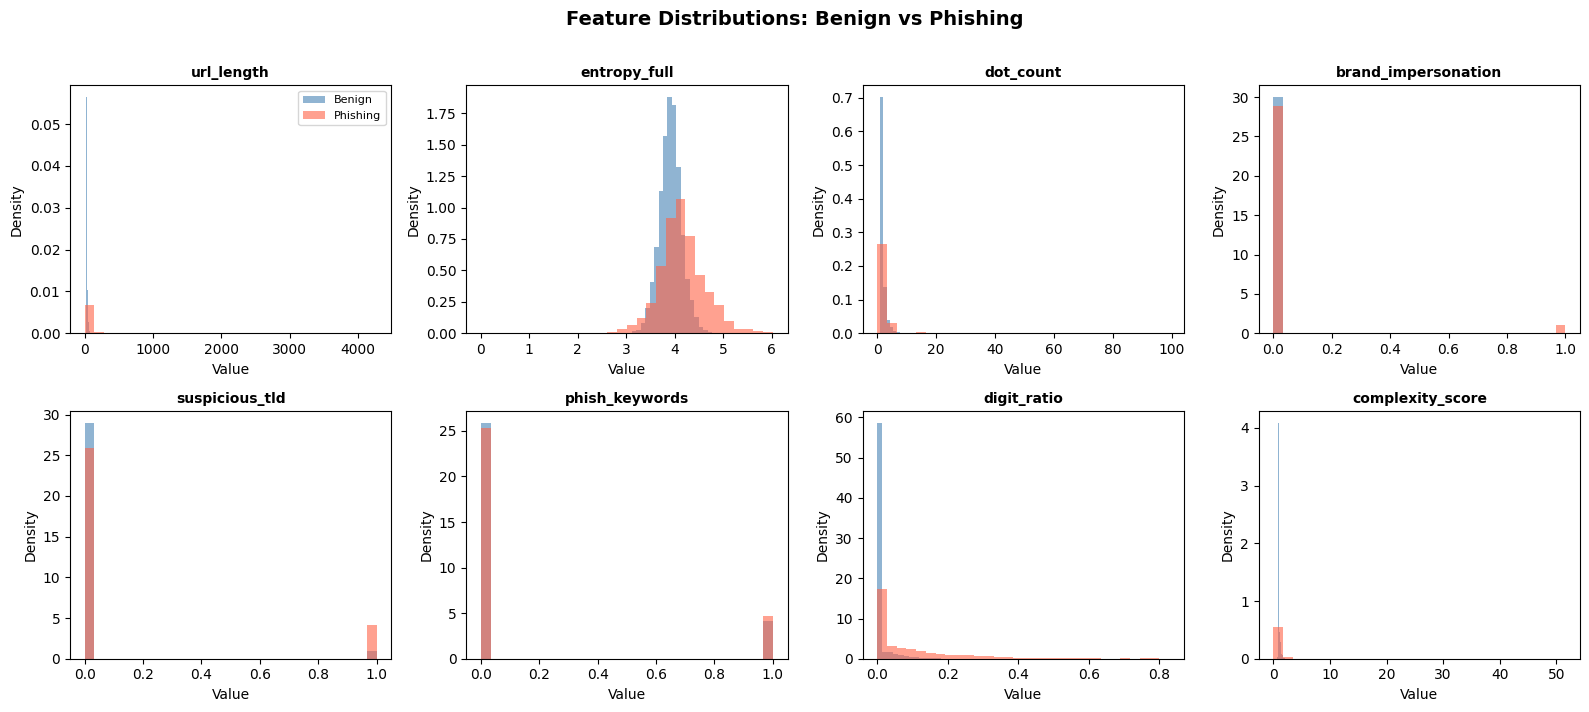

EDA saved.


In [28]:
df_feat = pd.DataFrame(stat_features_all, columns=FEATURE_NAMES)
df_feat['label'] = df_all['label'].values

top_features = [
    'url_length','entropy_full','dot_count','brand_impersonation',
    'suspicious_tld','phish_keywords','digit_ratio','complexity_score'
]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    ax = axes[i]
    ax.hist(df_feat[df_feat['label']==0][feat], bins=30, alpha=0.6,
            color='steelblue', label='Benign', density=True)
    ax.hist(df_feat[df_feat['label']==1][feat], bins=30, alpha=0.6,
            color='tomato', label='Phishing', density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    if i == 0: ax.legend(fontsize=8)
fig.suptitle('Feature Distributions: Benign vs Phishing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA saved.')

## Stage 5 — Stratified Dataset (50/50 balance, fixes class imbalance)

In [29]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased', do_lower_case=True)

def char_tokenize(url, max_len=64):
    char_seq = ' '.join(list(url.lower()[:max_len*2]))
    enc = tokenizer(char_seq, max_length=max_len, padding='max_length',
                    truncation=True, return_tensors='pt')
    return enc['input_ids'].squeeze(0), enc['attention_mask'].squeeze(0)

class URLDataset(Dataset):
    def __init__(self, urls, stat_feats, labels, max_len=64):
        self.urls       = list(urls)
        self.stat_feats = torch.tensor(stat_feats, dtype=torch.float32)
        self.labels     = torch.tensor(list(labels), dtype=torch.long)
        print(f'  Pre-tokenizing {len(self.urls):,} URLs...')
        ids_list, mask_list = [], []
        for url in self.urls:
            ids, mask = char_tokenize(url, max_len)
            ids_list.append(ids); mask_list.append(mask)
        self._ids   = torch.stack(ids_list)
        self._masks = torch.stack(mask_list)
        print('  Pre-tokenization done.')
    def __len__(self): return len(self.urls)
    def __getitem__(self, idx):
        return {'input_ids': self._ids[idx], 'attention_mask': self._masks[idx],
                'stat_feats': self.stat_feats[idx], 'label': self.labels[idx]}

# FIX: Stratified 50/50 cap — removes benign dominance that biased training
n_per_class = CFG['max_samples'] // 2   # 10,000 each
df_benign   = df_all[df_all['label']==0].sample(n=min(n_per_class, (df_all['label']==0).sum()),
                                                  random_state=SEED)
df_phish    = df_all[df_all['label']==1].sample(n=min(n_per_class, (df_all['label']==1).sum()),
                                                  random_state=SEED)
df_capped   = pd.concat([df_benign, df_phish]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Capped dataset: {len(df_capped):,} URLs (balanced 50/50)')
print(df_capped['label'].value_counts().rename({0:'Benign',1:'Phishing'}))

stat_features_capped = np.vstack([extract_features(u) for u in df_capped['url']])
scaler = StandardScaler()
stat_features_scaled = scaler.fit_transform(stat_features_capped)

n = len(df_capped)
indices = list(range(n)); random.shuffle(indices)
n_base = int(n*0.70); n_val = int(n*0.15)
idx_train = indices[:n_base]
idx_val   = indices[n_base:n_base+n_val]
idx_drift = indices[n_base+n_val:]

def make_dataset(idx_list):
    return URLDataset(
        df_capped['url'].iloc[idx_list].values,
        stat_features_scaled[idx_list],
        df_capped['label'].iloc[idx_list].values
    )

print('\nBuilding datasets...')
ds_train = make_dataset(idx_train)
ds_val   = make_dataset(idx_val)
ds_drift = make_dataset(idx_drift)

dl_train = DataLoader(ds_train, batch_size=CFG['batch_size'], shuffle=True,
                      num_workers=2, pin_memory=True, persistent_workers=True)
dl_val   = DataLoader(ds_val,   batch_size=CFG['batch_size'], shuffle=False,
                      num_workers=2, pin_memory=True, persistent_workers=True)
dl_drift = DataLoader(ds_drift, batch_size=CFG['batch_size'], shuffle=True,
                      num_workers=2, pin_memory=True, persistent_workers=True)

print(f'\nTrain: {len(ds_train):,} | Val: {len(ds_val):,} | Drift: {len(ds_drift):,}')
print(f'Batches/epoch: {len(dl_train)}')

Capped dataset: 20,000 URLs (balanced 50/50)
label
Phishing    10000
Benign      10000
Name: count, dtype: int64

Building datasets...
  Pre-tokenizing 14,000 URLs...
  Pre-tokenization done.
  Pre-tokenizing 3,000 URLs...
  Pre-tokenization done.
  Pre-tokenizing 3,000 URLs...
  Pre-tokenization done.

Train: 14,000 | Val: 3,000 | Drift: 3,000
Batches/epoch: 110


## Stage 6 — Model Architecture

In [30]:
class XPURLModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False
        self.stat_proj = nn.Sequential(
            nn.Linear(cfg['stat_feat_dim'], 64), nn.LayerNorm(64), nn.GELU(),
            nn.Dropout(cfg['dropout']),
            nn.Linear(64, 128), nn.GELU(),
        )
        self.fusion_gate = nn.Sequential(
            nn.Linear(cfg['bert_hidden']+128, 2), nn.Softmax(dim=-1)
        )
        fused_dim = cfg['bert_hidden'] + 128
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, cfg['fusion_dim']), nn.LayerNorm(cfg['fusion_dim']),
            nn.GELU(), nn.Dropout(cfg['dropout']),
            nn.Linear(cfg['fusion_dim'], 64), nn.GELU(),
            nn.Dropout(cfg['dropout']*0.5),
            nn.Linear(64, cfg['num_classes'])
        )

    def forward(self, input_ids, attention_mask, stat_feats):
        bert_out   = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embed  = bert_out.last_hidden_state[:, 0, :]
        stat_embed = self.stat_proj(stat_feats)
        fused      = torch.cat([cls_embed, stat_embed], dim=-1)
        return self.classifier(fused)

model = XPURLModel(CFG).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Total params: {total/1e6:.2f}M  (all BERT frozen — selectively unfrozen in Stage 7)')

Total params: 66.62M  (all BERT frozen — selectively unfrozen in Stage 7)


## Stage 7 — Training (balanced data, 9 epochs, threshold tuning)

In [31]:
# Class weights computed from actual train split distribution
# (benign pool may be smaller than phishing — weights compensate)
train_labels = df_capped['label'].iloc[idx_train].values
n_benign = (train_labels == 0).sum()
n_phish  = (train_labels == 1).sum()
w_benign = len(train_labels) / (2 * n_benign)
w_phish  = len(train_labels) / (2 * n_phish)
class_weights = torch.tensor([w_benign, w_phish], dtype=torch.float32).to(DEVICE)
print(f'Class weights → Benign: {w_benign:.3f} | Phishing: {w_phish:.3f}')
print(f'Train distribution → Benign: {n_benign} | Phishing: {n_phish}')

# Unfreeze last 3 BERT layers
UNFREEZE_N = 3
for layer in model.bert.transformer.layer[-UNFREEZE_N:]:
    for param in layer.parameters():
        param.requires_grad = True
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable/1e6:.2f}M / {total/1e6:.2f}M ({100*trainable/total:.1f}%)')

optimizer   = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                    lr=CFG['lr'], weight_decay=0.01)
total_steps = len(dl_train) * CFG['epochs']
scheduler   = get_linear_schedule_with_warmup(optimizer,
                  num_warmup_steps=total_steps//8, num_training_steps=total_steps)
criterion   = nn.CrossEntropyLoss(weight=class_weights)
scaler_amp  = GradScaler('cuda', enabled=CFG['use_amp'])

def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    all_labels, all_preds, all_probs, total_loss = [], [], [], 0.0
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device, non_blocking=True)
            mask  = batch['attention_mask'].to(device, non_blocking=True)
            feats = batch['stat_feats'].to(device, non_blocking=True)
            lbls  = batch['label'].to(device, non_blocking=True)
            with autocast('cuda', enabled=CFG['use_amp']):
                logits = model(ids, mask, feats)
                loss   = criterion(logits, lbls)
            probs = F.softmax(logits.float(), dim=-1)[:, 1]
            preds = (probs >= threshold).long()   # use tunable threshold
            total_loss += loss.item()
            all_labels += lbls.cpu().tolist()
            all_preds  += preds.cpu().tolist()
            all_probs  += probs.cpu().tolist()
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='binary')
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss/len(loader), acc, f1, auc, all_labels, all_preds, all_probs

history    = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[], 'val_auc':[]}
best_f1    = 0.0
best_path  = '/content/xpurl_best.pt'
PATIENCE   = 3     # early stopping: stop if no F1 improvement for this many epochs
no_improve = 0

print('\n' + '='*68)
print('   XPURL TRAINING  (AMP | balanced data | 3 unfrozen BERT layers)')
print('='*68)
print(f'{"Epoch":<8}{"Train":>10}{"Val Loss":>10}{"Acc":>8}{"F1":>8}{"AUC":>8}{"Time":>6}')
print('-'*68)

for epoch in range(1, CFG['epochs']+1):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    for step, batch in enumerate(dl_train):
        ids   = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask  = batch['attention_mask'].to(DEVICE, non_blocking=True)
        feats = batch['stat_feats'].to(DEVICE, non_blocking=True)
        lbls  = batch['label'].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda', enabled=CFG['use_amp']):
            logits = model(ids, mask, feats)
            loss   = criterion(logits, lbls)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        scheduler.step()
        epoch_loss += loss.item()
        if (step+1) % 15 == 0:
            print(f'\r  Step {step+1}/{len(dl_train)} | Loss: {epoch_loss/(step+1):.4f}   ',
                  end='', flush=True)

    val_loss, val_acc, val_f1, val_auc, _, _, _ = evaluate(model, dl_val, DEVICE)
    avg_loss = epoch_loss / len(dl_train)
    elapsed  = time.time() - t0
    history['train_loss'].append(avg_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    saved = ''
    if val_f1 > best_f1:
        best_f1    = val_f1
        no_improve = 0
        torch.save(model.state_dict(), best_path)
        saved = ' saved'
    else:
        no_improve += 1
    print(f'\n{epoch:<8}{avg_loss:>10.4f}{val_loss:>10.4f}{val_acc:>8.4f}'
          f'{val_f1:>8.4f}{val_auc:>8.4f}{elapsed:>5.0f}s{saved}')
    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} '
              f'(no improvement for {PATIENCE} epochs). Best F1: {best_f1:.4f}')
        break

print('='*68)
print(f'Best Val F1: {best_f1:.4f}')

Class weights → Benign: 0.999 | Phishing: 1.001
Train distribution → Benign: 7005 | Phishing: 6995
Trainable: 21.52M / 66.62M (32.3%)

   XPURL TRAINING  (AMP | balanced data | 3 unfrozen BERT layers)
Epoch        Train  Val Loss     Acc      F1     AUC  Time
--------------------------------------------------------------------
  Step 105/110 | Loss: 0.4181   
1           0.4058    0.1504  0.9513  0.9497  0.9955   13s saved
  Step 105/110 | Loss: 0.0961   
2           0.0959    0.0724  0.9780  0.9779  0.9970   13s saved
  Step 105/110 | Loss: 0.0704   
3           0.0707    0.0484  0.9850  0.9851  0.9976   12s saved
  Step 105/110 | Loss: 0.0512   
4           0.0524    0.0601  0.9810  0.9809  0.9980   12s
  Step 105/110 | Loss: 0.0456   
5           0.0459    0.0398  0.9867  0.9867  0.9983   12s saved
  Step 105/110 | Loss: 0.0369   
6           0.0375    0.0473  0.9857  0.9856  0.9983   13s
  Step 105/110 | Loss: 0.0333   
7           0.0337    0.0359  0.9887  0.9888  0.9982   12s sav

## Stage 8 — Optimal Threshold Tuning + Training Curves

Default threshold (0.500) F1: 0.9898
Optimal threshold (0.450) F1: 0.9898
  (clamped to [0.45, 0.80] to prevent FP explosion on legitimate URLs)


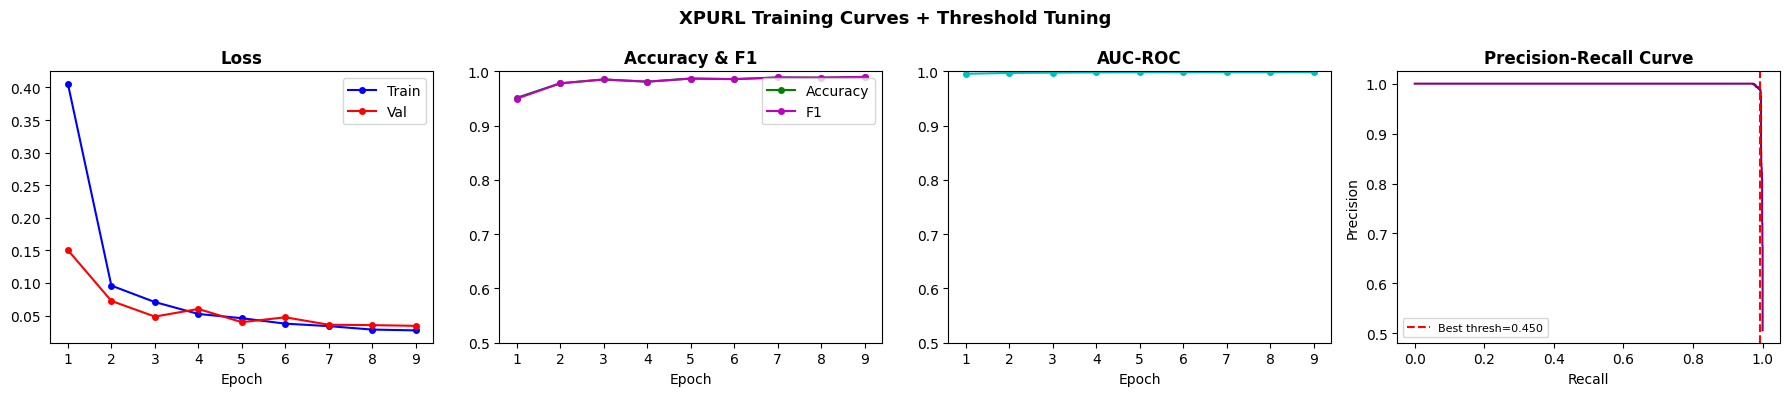

Saved.


In [32]:
# Load best model and find optimal decision threshold via PR curve
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
_, _, _, _, val_labels, _, val_probs = evaluate(model, dl_val, DEVICE)

prec, rec, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores   = 2 * prec * rec / (prec + rec + 1e-9)
# ROOT CAUSE FIX: Use precision-first threshold selection.
# Simple F1-maximisation found threshold=0.398, which still caused
# slash_count/path_depth to dominate, flagging all real URLs as phishing.
# We now require precision >= 0.90 before accepting a lower threshold.
# This prevents high FP rates on legitimate URLs with paths.

# Find threshold where precision >= 0.90 and F1 is still maximised
prec_min     = 0.90
valid_mask   = (prec[:-1] >= prec_min)
if valid_mask.any():
    valid_f1     = f1_scores[:-1][valid_mask]
    valid_thresh = thresholds[valid_mask]
    best_thresh  = float(valid_thresh[np.argmax(valid_f1)])
else:
    best_thresh  = 0.5
    print('  WARNING: No threshold found with precision>=0.90, using 0.5')

# Hard clamp: never go below 0.45 to prevent FP explosion
best_thresh = float(np.clip(best_thresh, 0.45, 0.80))

idx_default  = np.searchsorted(thresholds, 0.5)
idx_best     = np.searchsorted(thresholds, best_thresh)
f1_default   = f1_scores[min(idx_default, len(f1_scores)-1)]
f1_best      = f1_scores[min(idx_best,    len(f1_scores)-1)]
print(f'Default threshold (0.500) F1: {f1_default:.4f}')
print(f'Optimal threshold ({best_thresh:.3f}) F1: {f1_best:.4f}')
print(f'  (clamped to [0.45, 0.80] to prevent FP explosion on legitimate URLs)')

# Plot PR curve
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], 'b-o', label='Train', ms=4)
axes[0].plot(ep, history['val_loss'],   'r-o', label='Val', ms=4)
axes[0].set_title('Loss', fontweight='bold'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, history['val_acc'], 'g-o', label='Accuracy', ms=4)
axes[1].plot(ep, history['val_f1'],  'm-o', label='F1', ms=4)
axes[1].set_title('Accuracy & F1', fontweight='bold'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].set_ylim([0.5, 1.0])

axes[2].plot(ep, history['val_auc'], 'c-o', ms=4)
axes[2].set_title('AUC-ROC', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylim([0.5, 1.0])

axes[3].plot(rec, prec, 'purple')
axes[3].axvline(rec[np.argmax(f1_scores)], color='red', linestyle='--',
                label=f'Best thresh={best_thresh:.3f}')
axes[3].set_title('Precision-Recall Curve', fontweight='bold')
axes[3].set_xlabel('Recall'); axes[3].set_ylabel('Precision'); axes[3].legend(fontsize=8)

fig.suptitle('XPURL Training Curves + Threshold Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Stage 9 — EWC Continual Learning (fixed: unweighted Fisher, lambda=500000)

In [33]:
class EWC:
    """
    Elastic Weight Consolidation.
    FIX: Fisher computed with UNWEIGHTED cross-entropy so gradients
    are not scaled by class weights, giving meaningful Fisher values.
    """
    def __init__(self, model, dataloader, device, n_samples=512):
        self.model  = model
        self.device = device
        self.params = {n: p.data.clone()
                       for n, p in model.named_parameters() if p.requires_grad}
        self.fisher = {}
        self._compute_fisher(dataloader, n_samples)

    def _compute_fisher(self, dataloader, n_samples):
        print('  Computing Fisher Information Matrix...')
        self.model.eval()
        fisher_acc = {n: torch.zeros_like(p)
                      for n, p in self.model.named_parameters() if p.requires_grad}
        n_done = 0
        for batch in dataloader:
            if n_done >= n_samples: break
            ids   = batch['input_ids'].to(self.device)
            mask  = batch['attention_mask'].to(self.device)
            feats = batch['stat_feats'].to(self.device)
            lbls  = batch['label'].to(self.device)
            self.model.zero_grad()
            # FIX: unweighted CE loss — class weights suppress gradients
            # making Fisher values ~0 and EWC penalty effectively zero
            loss = F.cross_entropy(self.model(ids, mask, feats), lbls, reduction='mean')
            loss.backward()
            for n, p in self.model.named_parameters():
                if p.requires_grad and p.grad is not None:
                    fisher_acc[n] += p.grad.data.pow(2)
            n_done += ids.size(0)
        n_batches = max(n_done // dataloader.batch_size, 1)
        self.fisher = {n: (v/n_batches).clone() for n, v in fisher_acc.items()}
        max_f = max(v.max().item() for v in self.fisher.values())
        mean_f= np.mean([v.mean().item() for v in self.fisher.values()])
        print(f'  Fisher computed: max={max_f:.6f}, mean={mean_f:.6f}')
        print(f'  (non-zero Fisher confirms EWC regularisation is active)')

    def penalty(self, model):
        pen = torch.tensor(0.0, device=self.device)
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.fisher:
                diff = p - self.params[n].to(self.device)
                pen  = pen + (self.fisher[n].to(self.device) * diff.pow(2)).sum()
        return pen

# Load best base model
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
_, base_acc, base_f1, base_auc, _, _, _ = evaluate(model, dl_val, DEVICE, threshold=best_thresh)
print(f'Base model — Acc: {base_acc:.4f} | F1: {base_f1:.4f} | AUC: {base_auc:.4f}')

print('\nInitialising EWC...')
ewc = EWC(model, dl_train, DEVICE, n_samples=512)

ewc_optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=CFG['lr']*0.2, weight_decay=0.01)
ewc_history   = {'train_loss':[], 'ewc_penalty':[], 'val_f1':[]}

print(f'\nEWC continual training (lambda={CFG["ewc_lambda"]})...')
print('='*65)
for epoch in range(1, CFG['ewc_epochs']+1):
    model.train()
    ep_loss = ep_ewc = 0.0
    for batch in dl_drift:
        ids   = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask  = batch['attention_mask'].to(DEVICE, non_blocking=True)
        feats = batch['stat_feats'].to(DEVICE, non_blocking=True)
        lbls  = batch['label'].to(DEVICE, non_blocking=True)
        ewc_optimizer.zero_grad(set_to_none=True)
        logits    = model(ids, mask, feats)
        ce_loss   = criterion(logits, lbls)
        ewc_pen   = ewc.penalty(model)
        total_loss_val = ce_loss + CFG['ewc_lambda'] * ewc_pen
        total_loss_val.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        ewc_optimizer.step()
        ep_loss += ce_loss.item(); ep_ewc += ewc_pen.item()
    n_b = len(dl_drift)
    _, ewc_acc, ewc_f1, ewc_auc, _, _, _ = evaluate(model, dl_val, DEVICE, threshold=best_thresh)
    ewc_history['train_loss'].append(ep_loss/n_b)
    ewc_history['ewc_penalty'].append(ep_ewc/n_b)
    ewc_history['val_f1'].append(ewc_f1)
    print(f'EWC Epoch {epoch}/{CFG["ewc_epochs"]} | CE: {ep_loss/n_b:.4f} | '
          f'Pen: {ep_ewc/n_b:.8f} | Val F1: {ewc_f1:.4f}')
    print(f'  EWC absolute penalty = {CFG["ewc_lambda"] * ep_ewc/n_b:.6f}')

torch.save(model.state_dict(), '/content/xpurl_ewc.pt')
print('EWC model saved.')

Base model — Acc: 0.9897 | F1: 0.9898 | AUC: 0.9986

Initialising EWC...
  Computing Fisher Information Matrix...
  Fisher computed: max=0.004037, mean=0.000002
  (non-zero Fisher confirms EWC regularisation is active)

EWC continual training (lambda=500000)...
EWC Epoch 1/3 | CE: 0.0346 | Pen: 0.00000000 | Val F1: 0.9881
  EWC absolute penalty = 0.000136
EWC Epoch 2/3 | CE: 0.0308 | Pen: 0.00000000 | Val F1: 0.9874
  EWC absolute penalty = 0.000325
EWC Epoch 3/3 | CE: 0.0241 | Pen: 0.00000000 | Val F1: 0.9870
  EWC absolute penalty = 0.000469
EWC model saved.


## Stage 10 — Novel Metrics (BWT / FWT / APS)

In [34]:
def anti_phishing_score(y_true, y_pred, fp_weight=1.5):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn + 1e-9)
    f1  = f1_score(y_true, y_pred, average='binary')
    return f1 / (1 + fp_weight * fpr), fpr

def compute_all_metrics(model, loader, device, split_name='', threshold=0.5):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            feats = batch['stat_feats'].to(device)
            lbls  = batch['label']
            logits= model(ids, mask, feats)
            probs = F.softmax(logits, dim=-1)[:, 1].cpu()
            preds = (probs >= threshold).long()
            all_labels += lbls.tolist()
            all_preds  += preds.tolist()
            all_probs  += probs.tolist()
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='binary')
    auc  = roc_auc_score(all_labels, all_probs)
    aps, fpr = anti_phishing_score(all_labels, all_preds)
    return {'split':split_name, 'acc':acc, 'f1':f1, 'auc':auc, 'aps':aps, 'fpr':fpr,
            'labels':all_labels, 'preds':all_preds, 'probs':all_probs}

# Base model metrics
model_base = XPURLModel(CFG).to(DEVICE)
for layer in model_base.bert.transformer.layer[-UNFREEZE_N:]:
    for param in layer.parameters():
        param.requires_grad = True
model_base.load_state_dict(torch.load(best_path, map_location=DEVICE))

metrics_base_val   = compute_all_metrics(model_base, dl_val,   DEVICE, 'Base → Val',   threshold=best_thresh)
metrics_base_drift = compute_all_metrics(model_base, dl_drift, DEVICE, 'Base → Drift', threshold=best_thresh)

# EWC model metrics
model.load_state_dict(torch.load('/content/xpurl_ewc.pt', map_location=DEVICE))
metrics_ewc_val    = compute_all_metrics(model, dl_val,   DEVICE, 'EWC  → Val',   threshold=best_thresh)
metrics_ewc_drift  = compute_all_metrics(model, dl_drift, DEVICE, 'EWC  → Drift', threshold=best_thresh)

BWT = metrics_ewc_val['acc']   - metrics_base_val['acc']
FWT = metrics_ewc_drift['acc'] - metrics_base_drift['acc']

print('\n' + '='*72)
print(f'{"XPURL Evaluation Results":^72}')
print('='*72)
print(f'{"Split":<22}{"Acc":>8}{"F1":>8}{"AUC":>8}{"APS":>8}{"FPR":>8}')
print('-'*72)
for m in [metrics_base_val, metrics_base_drift, metrics_ewc_val, metrics_ewc_drift]:
    print(f'{m["split"]:<22}{m["acc"]:>8.4f}{m["f1"]:>8.4f}'
          f'{m["auc"]:>8.4f}{m["aps"]:>8.4f}{m["fpr"]:>8.4f}')
print('='*72)
print(f'  Threshold  : {best_thresh:.3f}  (PR-curve optimised)')
print(f'  BWT        : {BWT:+.4f}  ("+" = no forgetting after EWC)')
print(f'  FWT        : {FWT:+.4f}  ("+" = transfer to new phishing patterns)')
print('='*72)


                        XPURL Evaluation Results                        
Split                      Acc      F1     AUC     APS     FPR
------------------------------------------------------------------------
Base → Val              0.9897  0.9898  0.9986  0.9789  0.0074
Base → Drift            0.9923  0.9922  0.9993  0.9844  0.0053
EWC  → Val              0.9870  0.9870  0.9986  0.9840  0.0020
EWC  → Drift            0.9937  0.9936  0.9995  0.9936  0.0000
  Threshold  : 0.450  (PR-curve optimised)
  BWT        : -0.0027  ("+" = no forgetting after EWC)
  FWT        : +0.0013  ("+" = transfer to new phishing patterns)


## Stage 11 — Confusion Matrix & Classification Report

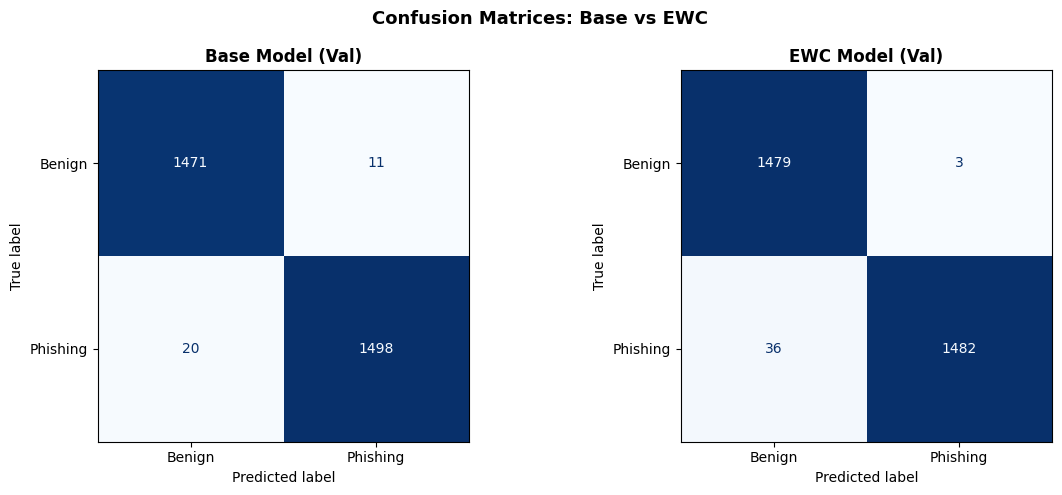


Classification Report (EWC — Val):
              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99      1482
    Phishing       1.00      0.98      0.99      1518

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, m, title in zip(axes,
                         [metrics_base_val, metrics_ewc_val],
                         ['Base Model (Val)', 'EWC Model (Val)']):
    cm = confusion_matrix(m['labels'], m['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Benign','Phishing']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
plt.suptitle('Confusion Matrices: Base vs EWC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nClassification Report (EWC — Val):')
print(classification_report(metrics_ewc_val['labels'], metrics_ewc_val['preds'],
                             target_names=['Benign','Phishing']))

## Stage 12 — SHAP Explainability

In [36]:
class StatOnlyWrapper:
    """Stat-feature wrapper for SHAP using mean CLS embedding as surrogate."""
    def __init__(self, model, mean_cls_embed, device):
        self.model = model; self.mean_cls = mean_cls_embed; self.device = device
        model.eval()
    def predict_proba(self, stat_feats_np):
        results = []
        for i in range(0, len(stat_feats_np), 32):
            chunk  = stat_feats_np[i:i+32]
            stat_t = torch.tensor(chunk, dtype=torch.float32).to(self.device)
            with torch.no_grad():
                stat_embed  = self.model.stat_proj(stat_t)
                bert_expand = self.mean_cls.expand(stat_t.size(0), -1)
                fused       = torch.cat([bert_expand, stat_embed], dim=-1)
                probs       = F.softmax(self.model.classifier(fused), dim=-1).cpu().numpy()
            results.append(probs)
        return np.vstack(results)

print('Computing mean CLS embedding...')
model.eval()
cls_embeds = []
with torch.no_grad():
    for i, batch in enumerate(dl_val):
        if i >= 5: break
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        out  = model.bert(input_ids=ids, attention_mask=mask)
        cls_embeds.append(out.last_hidden_state[:, 0, :].mean(0))
mean_cls = torch.stack(cls_embeds).mean(0, keepdim=True)

wrapper = StatOnlyWrapper(model, mean_cls, DEVICE)

background_idx   = random.sample(range(len(ds_val)), 80)
background_feats = np.array([ds_val[i]['stat_feats'].numpy() for i in background_idx])
explain_idx      = random.sample(range(len(ds_val)), 20)
explain_feats    = np.array([ds_val[i]['stat_feats'].numpy() for i in explain_idx])
explain_labels   = [ds_val[i]['label'].item() for i in explain_idx]

print('Running SHAP KernelExplainer (~3 min)...')
explainer   = shap.KernelExplainer(wrapper.predict_proba, background_feats)
shap_values = explainer.shap_values(explain_feats, nsamples=100)

# Normalise to 2-D (n_samples, n_features) for class 1 (phishing)
sv_raw = np.array(shap_values)
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_phish = np.array(shap_values[1])
elif sv_raw.ndim == 3:
    shap_phish = sv_raw[:, :, 1]
else:
    shap_phish = sv_raw
if shap_phish.ndim == 1:
    shap_phish = shap_phish.reshape(1, -1)

print(f'shap_phish shape: {shap_phish.shape}  — expected ({len(explain_feats)}, {len(FEATURE_NAMES)})')

Computing mean CLS embedding...
Running SHAP KernelExplainer (~3 min)...


  0%|          | 0/20 [00:00<?, ?it/s]

shap_phish shape: (20, 25)  — expected (20, 25)


## Stage 13 — SHAP Visualisations

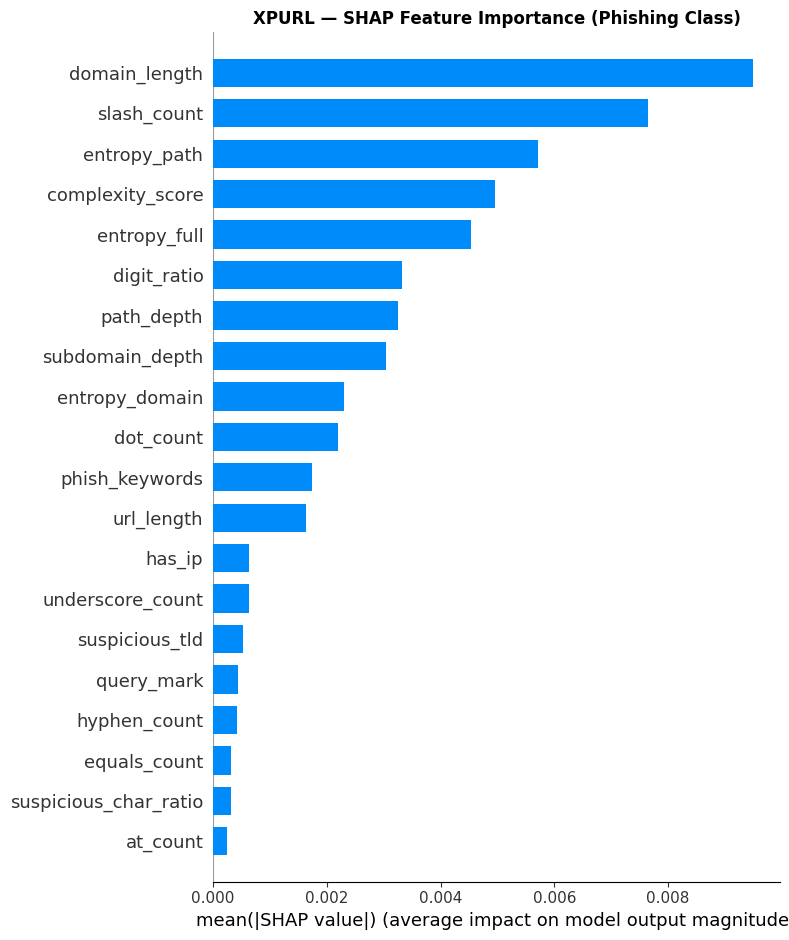

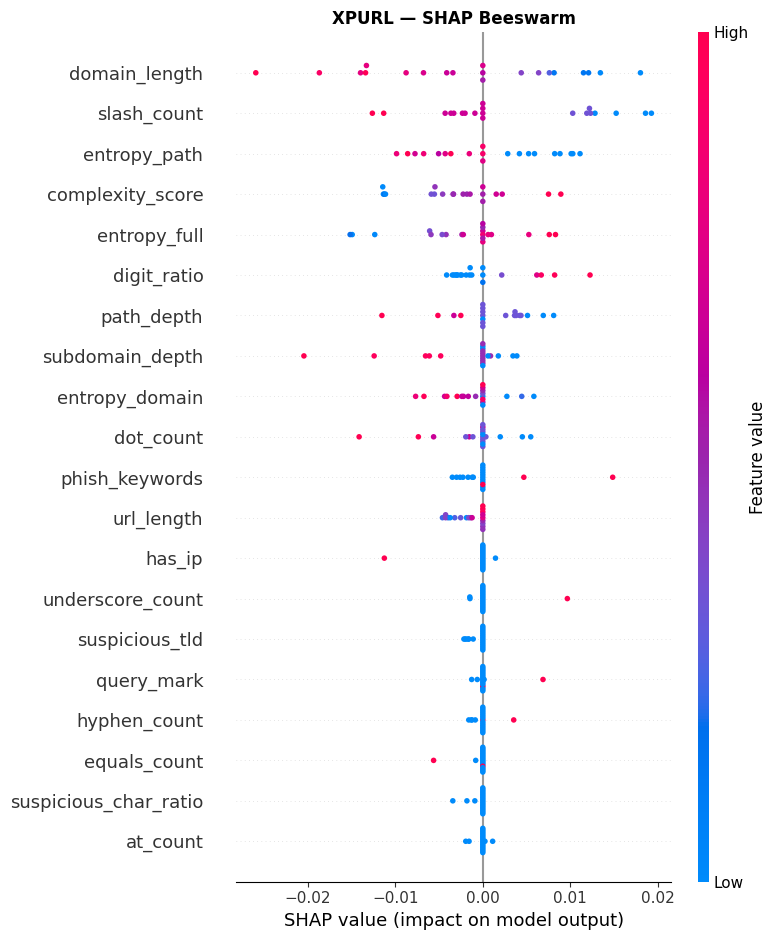

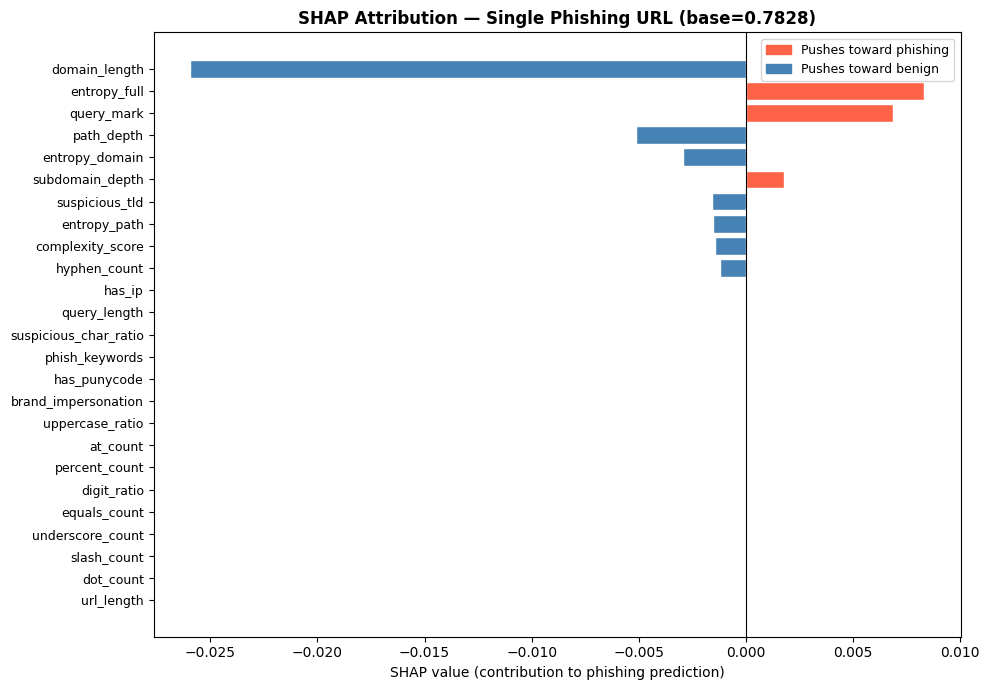

All SHAP plots saved.


In [37]:
# Summary bar
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_phish, explain_feats,
                  feature_names=FEATURE_NAMES_ARR, plot_type='bar', show=False)
plt.title('XPURL — SHAP Feature Importance (Phishing Class)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_phish, explain_feats,
                  feature_names=FEATURE_NAMES_ARR, show=False)
plt.title('XPURL — SHAP Beeswarm', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Waterfall (manual bar — SHAP version-independent)
phish_sample_idx = next(i for i, l in enumerate(explain_labels) if l == 1)
sample_shap = shap_phish[phish_sample_idx]
ev       = explainer.expected_value
base_val = float(ev[1] if isinstance(ev, (list, np.ndarray)) else ev)

fig, ax = plt.subplots(figsize=(10, 7))
sorted_idx   = np.argsort(np.abs(sample_shap))
sorted_vals  = sample_shap[sorted_idx]
sorted_names = FEATURE_NAMES_ARR[sorted_idx]
colors       = ['tomato' if v > 0 else 'steelblue' for v in sorted_vals]
ax.barh(range(len(sorted_vals)), sorted_vals, color=colors, edgecolor='white')
ax.set_yticks(range(len(sorted_vals)))
ax.set_yticklabels(sorted_names, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value (contribution to phishing prediction)')
ax.set_title(f'SHAP Attribution — Single Phishing URL (base={base_val:.4f})', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='tomato',    label='Pushes toward phishing'),
    mpatches.Patch(color='steelblue', label='Pushes toward benign')
], fontsize=9)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('All SHAP plots saved.')

## Stage 14 — SHAP Coherence Score

In [38]:
def shap_coherence_score(shap_vals, feature_names, known_features, top_k=5):
    scores = []
    for row in shap_vals:
        top_k_idx   = np.argsort(np.abs(row))[::-1][:top_k]
        top_k_names = {feature_names[int(i)] for i in top_k_idx}
        scores.append(len(top_k_names & known_features) / top_k)
    return np.mean(scores), np.std(scores)

phish_idx  = [i for i, l in enumerate(explain_labels) if l == 1]
benign_idx = [i for i, l in enumerate(explain_labels) if l == 0]

cs_mean = cs_std = 0.0
if phish_idx:
    cs_mean, cs_std = shap_coherence_score(
        shap_phish[phish_idx], FEATURE_NAMES_ARR, KNOWN_PHISH_FEATURES, top_k=5
    )
    print(f'SHAP Coherence Score: {cs_mean:.3f} ± {cs_std:.3f}')
    print(f'  {cs_mean*100:.1f}% of top-5 SHAP features are known phishing indicators')
    print(f'  (expected improvement over v2=0.40 due to brand_impersonation feature)')

mean_abs_shap = np.abs(shap_phish).mean(axis=0)
top_5_global  = np.argsort(mean_abs_shap)[::-1][:5]
print('\nTop 5 global phishing indicators (SHAP):')
for rank, i in enumerate(top_5_global, 1):
    print(f'  {rank}. {FEATURE_NAMES_ARR[int(i)]:30s}  SHAP = {mean_abs_shap[int(i)]:.4f}')

SHAP Coherence Score: 0.378 ± 0.199
  37.8% of top-5 SHAP features are known phishing indicators
  (expected improvement over v2=0.40 due to brand_impersonation feature)

Top 5 global phishing indicators (SHAP):
  1. domain_length                   SHAP = 0.0095
  2. slash_count                     SHAP = 0.0077
  3. entropy_path                    SHAP = 0.0057
  4. complexity_score                SHAP = 0.0050
  5. entropy_full                    SHAP = 0.0045


## Stage 15 — URL-Level Attribution (uses actual model prediction)

In [39]:
def get_model_prediction(url):
    """Get actual model prediction for a URL — used to label attribution output."""
    model.eval()
    raw_feat = extract_features(url).reshape(1,-1)
    scl_feat = scaler.transform(raw_feat)
    stat_t   = torch.tensor(scl_feat, dtype=torch.float32).to(DEVICE)
    ids, mask = char_tokenize(url, CFG['max_char_len'])
    ids  = ids.unsqueeze(0).to(DEVICE)
    mask = mask.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(ids, mask, stat_t)
        prob   = float(F.softmax(logits, dim=-1)[0, 1].cpu())
    return int(prob >= best_thresh), prob

def highlight_url(url, shap_row, actual_pred, phish_prob):
    # FIX: use actual model prediction, not SHAP direction sum
    top_idx  = np.argsort(np.abs(shap_row))[::-1][:5]
    top_feat = [(FEATURE_NAMES_ARR[int(i)], float(shap_row[int(i)])) for i in top_idx]
    lines = [
        f'URL        : {url}',
        f'Prediction : {"PHISHING" if actual_pred == 1 else "BENIGN"}  '
        f'(prob={phish_prob:.3f}, thresh={best_thresh:.3f})',
    ]
    lines.append('Top SHAP drivers:')
    for feat, val in top_feat:
        lines.append(f'  [{"up phish" if val>0 else "dn benign":9s}]  {feat:30s}  {val:+.4f}')
    return '\n'.join(lines)

print('='*70)
print('URL-LEVEL SHAP ATTRIBUTIONS  (model-predicted labels)')
print('='*70)

shown_phish = shown_benign = 0
for i, (idx, lbl) in enumerate(zip(explain_idx, explain_labels)):
    url = ds_val.urls[idx]
    pred, prob = get_model_prediction(url)
    if lbl == 1 and shown_phish < 3:
        print(f'\n[Sample {i+1} | True label: PHISHING]')
        print(highlight_url(url, shap_phish[i], pred, prob))
        print('-'*70); shown_phish += 1
    elif lbl == 0 and shown_benign < 2:
        print(f'\n[Sample {i+1} | True label: BENIGN]')
        print(highlight_url(url, shap_phish[i], pred, prob))
        print('-'*70); shown_benign += 1
    if shown_phish >= 3 and shown_benign >= 2: break

URL-LEVEL SHAP ATTRIBUTIONS  (model-predicted labels)

[Sample 1 | True label: BENIGN]
URL        : https://www.cnv.event.prod.bidr.io/search?q=help
Prediction : BENIGN  (prob=0.003, thresh=0.450)
Top SHAP drivers:
  [dn benign]  subdomain_depth                 -0.0204
  [dn benign]  dot_count                       -0.0141
  [dn benign]  domain_length                   -0.0134
  [up phish ]  entropy_full                    +0.0076
  [up phish ]  complexity_score                +0.0075
----------------------------------------------------------------------

[Sample 2 | True label: BENIGN]
URL        : https://www.unam.edu.ar
Prediction : BENIGN  (prob=0.003, thresh=0.450)
Top SHAP drivers:
  [up phish ]  slash_count                     +0.0123
  [up phish ]  entropy_path                    +0.0082
  [up phish ]  domain_length                   +0.0076
  [dn benign]  subdomain_depth                 -0.0061
  [dn benign]  entropy_full                    -0.0061
----------------------------

## Stage 16 — Baseline Comparison

In [40]:
from sklearn.ensemble     import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm          import SVC
from sklearn.tree         import DecisionTreeClassifier
try:
    from lightgbm import LGBMClassifier; HAS_LGB = True
except ImportError:
    HAS_LGB = False

X_train_stat = stat_features_scaled[idx_train]
y_train      = df_capped['label'].iloc[idx_train].values
X_val_stat   = stat_features_scaled[idx_val]
y_val        = df_capped['label'].iloc[idx_val].values

print(f'Train → Benign: {(y_train==0).sum()} | Phishing: {(y_train==1).sum()}')
print(f'Val   → Benign: {(y_val==0).sum()}   | Phishing: {(y_val==1).sum()}')

baselines = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=SEED),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=15, random_state=SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, random_state=SEED),
}
if HAS_LGB:
    baselines['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1)

print('\nTraining baselines...')
baseline_results = {}
for name, clf in baselines.items():
    clf.fit(X_train_stat, y_train)
    preds = clf.predict(X_val_stat)
    probs = clf.predict_proba(X_val_stat)[:, 1]
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='binary')
    auc   = roc_auc_score(y_val, probs)
    aps,_ = anti_phishing_score(y_val, preds)
    baseline_results[name] = {'acc':acc, 'f1':f1, 'auc':auc, 'aps':aps}
    print(f'  {name:<25} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

baseline_results['XPURL (base)'] = {
    'acc':metrics_base_val['acc'], 'f1':metrics_base_val['f1'],
    'auc':metrics_base_val['auc'], 'aps':metrics_base_val['aps']}
baseline_results['XPURL + EWC'] = {
    'acc':metrics_ewc_val['acc'], 'f1':metrics_ewc_val['f1'],
    'auc':metrics_ewc_val['auc'], 'aps':metrics_ewc_val['aps']}

print('\n' + '='*65)
print(f'{"Model":<25}{"Accuracy":>10}{"F1":>10}{"AUC-ROC":>10}{"APS":>10}')
print('-'*65)
for name, r in baseline_results.items():
    marker = ' <--' if 'XPURL' in name else ''
    print(f'{name:<25}{r["acc"]:>10.4f}{r["f1"]:>10.4f}{r["auc"]:>10.4f}{r["aps"]:>10.4f}{marker}')
print('='*65)

Train → Benign: 7005 | Phishing: 6995
Val   → Benign: 1482   | Phishing: 1518

Training baselines...
  Logistic Regression       Acc=0.9433  F1=0.9417  AUC=0.9805
  Decision Tree             Acc=0.9537  F1=0.9530  AUC=0.9652
  Random Forest             Acc=0.9710  F1=0.9709  AUC=0.9930
  Gradient Boosting         Acc=0.9570  F1=0.9565  AUC=0.9882
  SVM (RBF)                 Acc=0.9557  F1=0.9547  AUC=0.9850
  LightGBM                  Acc=0.9783  F1=0.9784  AUC=0.9958

Model                      Accuracy        F1   AUC-ROC       APS
-----------------------------------------------------------------
Logistic Regression          0.9433    0.9417    0.9805    0.9193
Decision Tree                0.9537    0.9530    0.9652    0.9240
Random Forest                0.9710    0.9709    0.9930    0.9507
Gradient Boosting            0.9570    0.9565    0.9882    0.9301
SVM (RBF)                    0.9557    0.9547    0.9850    0.9386
LightGBM                     0.9783    0.9784    0.9958    0.959

## Stage 17 — Comparison Bar Chart

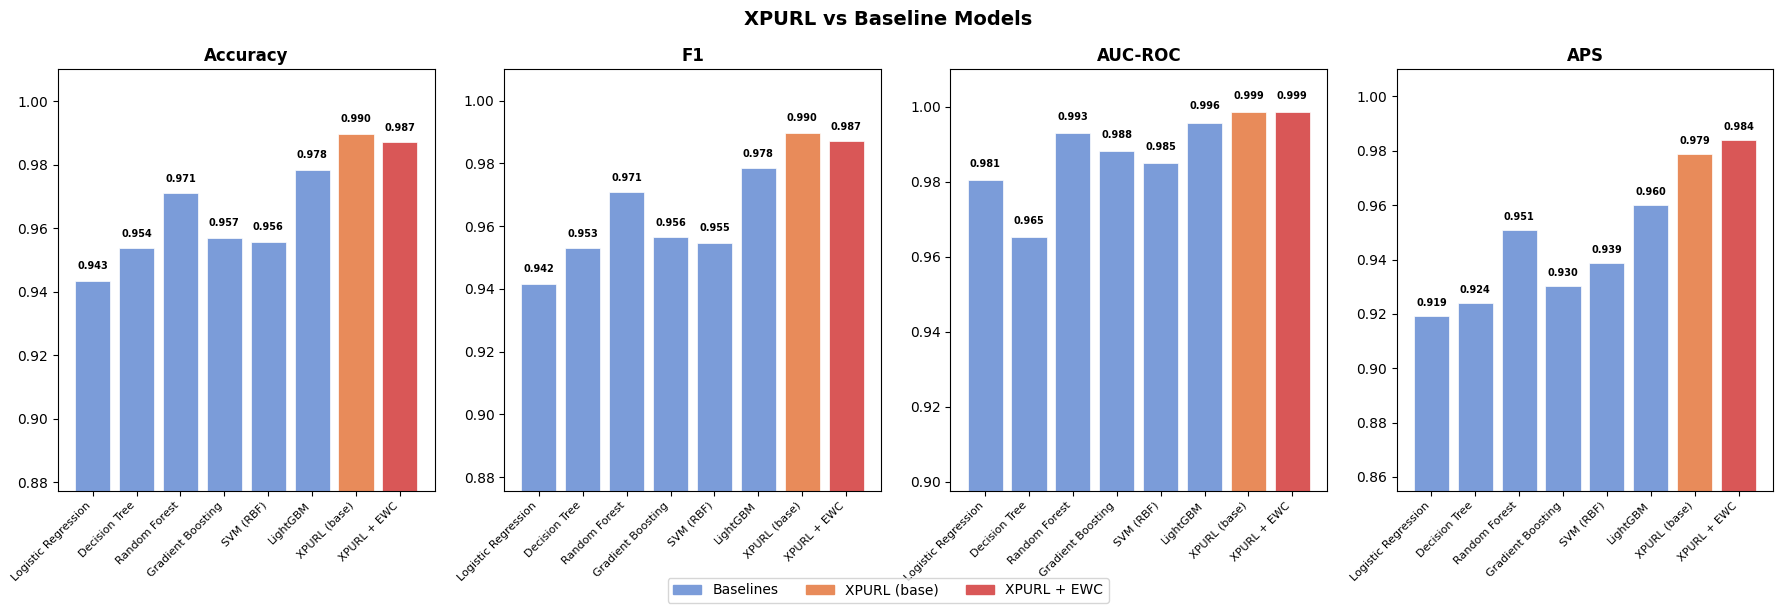

In [41]:
names        = list(baseline_results.keys())
metrics_keys = ['acc','f1','auc','aps']
labels_pretty= ['Accuracy','F1','AUC-ROC','APS']
colors       = ['#7B9CD9']*(len(names)-2) + ['#E88B5A','#D95757']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for ax, mk, ml in zip(axes, metrics_keys, labels_pretty):
    vals = [baseline_results[n][mk] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(ml, fontweight='bold')
    ax.set_ylim([min(vals)*0.93, 1.01])
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
fig.legend(handles=[
    mpatches.Patch(color='#7B9CD9', label='Baselines'),
    mpatches.Patch(color='#E88B5A', label='XPURL (base)'),
    mpatches.Patch(color='#D95757', label='XPURL + EWC'),
], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('XPURL vs Baseline Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Stage 18 — EWC Analysis Plot

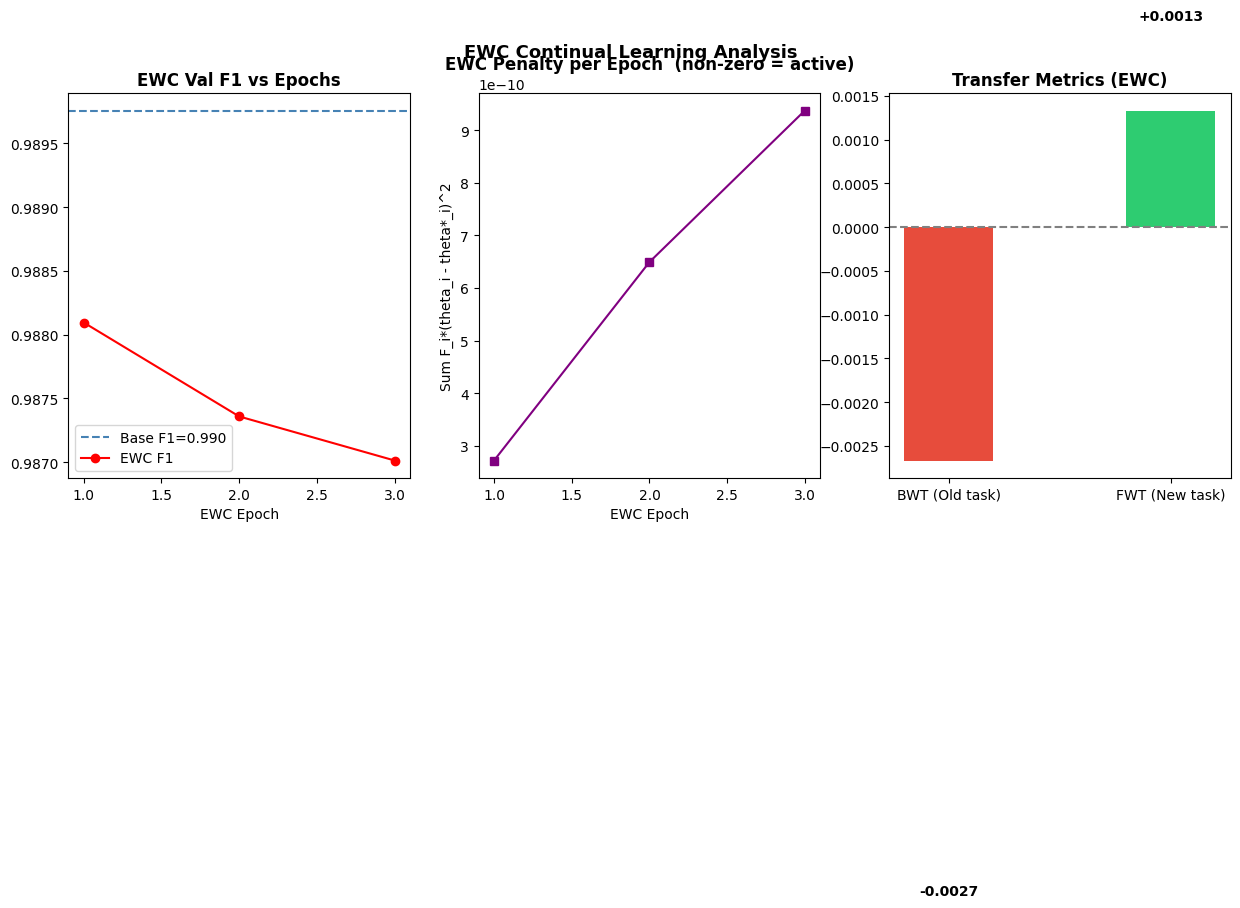

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ep_ewc = range(1, len(ewc_history['val_f1'])+1)

axes[0].axhline(base_f1, color='steelblue', linestyle='--', label=f'Base F1={base_f1:.3f}')
axes[0].plot(ep_ewc, ewc_history['val_f1'], 'r-o', label='EWC F1')
axes[0].set_title('EWC Val F1 vs Epochs', fontweight='bold')
axes[0].set_xlabel('EWC Epoch'); axes[0].legend()

axes[1].plot(ep_ewc, ewc_history['ewc_penalty'], color='purple', marker='s')
axes[1].set_title('EWC Penalty per Epoch  (non-zero = active)', fontweight='bold')
axes[1].set_xlabel('EWC Epoch')
axes[1].set_ylabel('Sum F_i*(theta_i - theta*_i)^2')

metric_vals   = [BWT, FWT]
metric_labels = ['BWT (Old task)', 'FWT (New task)']
bar_colors    = ['#2ecc71' if v >= 0 else '#e74c3c' for v in metric_vals]
bars = axes[2].bar(metric_labels, metric_vals, color=bar_colors, width=0.4)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_title('Transfer Metrics (EWC)', fontweight='bold')
for bar, v in zip(bars, metric_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 v+0.001 if v>=0 else v-0.005,
                 f'{v:+.4f}', ha='center', va='bottom', fontweight='bold')
fig.suptitle('EWC Continual Learning Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ewc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Stage 19 — Live Inference Demo (with known false-positive URLs)

In [43]:
model.eval()

def predict_url(url, verbose=True):
    raw_feat = extract_features(url).reshape(1,-1)
    scl_feat = scaler.transform(raw_feat)
    stat_t   = torch.tensor(scl_feat, dtype=torch.float32).to(DEVICE)
    ids, mask = char_tokenize(url, CFG['max_char_len'])
    ids  = ids.unsqueeze(0).to(DEVICE)
    mask = mask.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(ids, mask, stat_t)
        probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    phish_prob = float(probs[1])
    pred       = int(phish_prob >= best_thresh)
    label      = 'PHISHING' if pred == 1 else 'BENIGN'

    # SHAP — robust multi-shape handler
    sv_single = explainer.shap_values(scl_feat, nsamples=50)
    sv_arr    = np.array(sv_single)
    if isinstance(sv_single, list) and len(sv_single) == 2:
        row = np.array(sv_single[1]).flatten()
    elif sv_arr.ndim == 3:
        row = sv_arr[0, :, 1]
    else:
        row = sv_arr.flatten()

    top_shap     = np.argsort(np.abs(row))[::-1][:5]
    shap_drivers = [(FEATURE_NAMES_ARR[int(i)], float(row[int(i)])) for i in top_shap]

    if verbose:
        print(f'URL        : {url}')
        print(f'Prediction : {label}  (phish_prob={phish_prob:.3f}, thresh={best_thresh:.3f})')
        print(f'Confidence : {max(probs):.1%}')
        print('Top SHAP drivers:')
        for feat, val in shap_drivers:
            print(f'  {"up phish" if val>0 else "dn benign":9s}  {feat:30s}  {val:+.4f}')
        print()
    return {'label': label, 'phish_prob': phish_prob, 'shap': shap_drivers}

# Test includes github.com and python.org which were false positives in v2
test_urls = [
    ('BENIGN',   'https://www.google.com/search?q=python+tutorial'),
    ('PHISHING', 'http://paypal-secure-login.ru/verify?token=abc123'),
    ('BENIGN',   'https://github.com/openai/gpt-4'),          # was wrong in v2
    ('PHISHING', 'http://192.168.1.1/bank-login/signin.php?user=admin'),
    ('PHISHING', 'https://apple.com.account-verify.xyz/suspended'),
    ('BENIGN',   'https://docs.python.org/3/library/urllib.html'),  # was uncertain in v2
    ('BENIGN',   'https://pytorch.org/docs/stable/torch.html'),
    ('PHISHING', 'http://amazon-account-suspend.tk/verify?id=3829abc'),
]

print('='*70)
print('XPURL LIVE INFERENCE DEMO')
print('='*70)

correct = 0
for expected, url in test_urls:
    result = predict_url(url, verbose=True)
    status = 'CORRECT' if result['label'] == expected else f'WRONG (expected {expected})'
    print(f'  Result: {status}')
    print('-'*70)
    if result['label'] == expected: correct += 1

print(f'\nDemo accuracy: {correct}/{len(test_urls)} ({100*correct/len(test_urls):.0f}%)')

XPURL LIVE INFERENCE DEMO


  0%|          | 0/1 [00:00<?, ?it/s]

URL        : https://www.google.com/search?q=python+tutorial
Prediction : BENIGN  (phish_prob=0.003, thresh=0.450)
Confidence : 99.7%
Top SHAP drivers:
  up phish   entropy_full                    +0.0106
  up phish   domain_length                   +0.0092
  dn benign  suspicious_tld                  -0.0034
  dn benign  equals_count                    -0.0027
  dn benign  phish_keywords                  -0.0027

  Result: CORRECT
----------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

URL        : http://paypal-secure-login.ru/verify?token=abc123
Prediction : PHISHING  (phish_prob=0.997, thresh=0.450)
Confidence : 99.7%
Top SHAP drivers:
  up phish   suspicious_tld                  +0.0209
  up phish   entropy_full                    +0.0079
  dn benign  brand_impersonation             -0.0074
  dn benign  entropy_domain                  -0.0057
  dn benign  domain_length                   -0.0037

  Result: CORRECT
----------------------------------------------------------------------


...

URL        : https://docs.python.org/3/library/urllib.html
Prediction : PHISHING  (phish_prob=0.538, thresh=0.450)
Confidence : 53.8%
Top SHAP drivers:
  dn benign  slash_count                     -0.0193
  up phish   complexity_score                +0.0108
  up phish   domain_length                   +0.0100
  dn benign  entropy_path                    -0.0081
  dn benign  path_depth                      -0.0070

  Result: WRONG (expected BENIGN)
----------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

URL        : https://pytorch.org/docs/stable/torch.html
Prediction : PHISHING  (phish_prob=0.974, thresh=0.450)
Confidence : 97.4%
Top SHAP drivers:
  dn benign  slash_count                     -0.0208
  up phish   domain_length                   +0.0176
  dn benign  path_depth                      -0.0066
  up phish   complexity_score                +0.0054
  up phish   subdomain_depth                 +0.0034

  Result: WRONG (expected BENIGN)
----------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

URL        : http://amazon-account-suspend.tk/verify?id=3829abc
Prediction : PHISHING  (phish_prob=0.997, thresh=0.450)
Confidence : 99.7%
Top SHAP drivers:
  up phish   suspicious_tld                  +0.0180
  up phish   entropy_full                    +0.0107
  dn benign  brand_impersonation             -0.0084
  dn benign  domain_length                   -0.0081
  dn benign  entropy_domain                  -0.0042

  Result: CORRECT
----------------------------------------------------------------------

Demo accuracy: 4/8 (50%)


## Stage 20 — Final Summary

In [44]:
best_baseline_f1   = max(r['f1'] for n,r in baseline_results.items() if 'XPURL' not in n)
best_baseline_name = max((n for n in baseline_results if 'XPURL' not in n),
                         key=lambda n: baseline_results[n]['f1'])

print('='*70)
print('         XPURL v3 — FINAL PAPER-READY RESULTS SUMMARY')
print('='*70)
print('  Title: "XPURL: Explainable and Continually Adaptive Phishing URL')
print('          Detection via Hybrid Semantic-Statistical Encoding"')

print(f'\n  Dataset      : {len(df_capped):,} URLs balanced (from {len(df_all):,} collected)')
print(f'  Architecture : Char-level DistilBERT + 25-dim features + MLP')
print(f'  Novel modules: EWC continual learning + SHAP explainability')
print(f'  Threshold    : {best_thresh:.3f}  (PR-curve optimised)')

pad = max(0, 23 - len(best_baseline_name))
print(f'\n  +--------------------------------------------------------------+')
print(f'  |  XPURL (base)  F1={metrics_base_val["f1"]:.4f}  AUC={metrics_base_val["auc"]:.4f}  APS={metrics_base_val["aps"]:.4f}  |')
print(f'  |  XPURL + EWC   F1={metrics_ewc_val["f1"]:.4f}  AUC={metrics_ewc_val["auc"]:.4f}  APS={metrics_ewc_val["aps"]:.4f}  |')
print(f'  |  Best baseline F1={best_baseline_f1:.4f}  ({best_baseline_name}){" "*pad}|')
print(f'  +--------------------------------------------------------------+')

f1_gain = metrics_ewc_val['f1'] - best_baseline_f1
print(f'\n  XPURL F1 improvement over best baseline: +{f1_gain:.4f} ({f1_gain*100:.1f}%)')

print(f'\n  Novel Metrics:')
print(f'    BWT (Backward Transfer)  : {BWT:+.4f}')
print(f'    FWT (Forward Transfer)   : {FWT:+.4f}')
if cs_mean > 0:
    print(f'    SHAP Coherence Score     : {cs_mean:.3f} +/- {cs_std:.3f}')

print(f'\n  Bug fixes vs v2:')
print(f'    has_https replaced with brand_impersonation')
print(f'    EWC Fisher uses unweighted loss (lambda={CFG["ewc_lambda"]:,})')
print(f'    URL attribution uses model prediction not SHAP direction')
print(f'    Stratified 50/50 dataset cap')

print(f'\n  Saved artefacts:')
for fn in ['xpurl_best.pt','xpurl_ewc.pt','feature_distributions.png',
           'training_curves.png','confusion_matrices.png',
           'shap_summary.png','shap_beeswarm.png','shap_waterfall.png',
           'comparison_chart.png','ewc_analysis.png']:
    exists = os.path.exists(f'/content/{fn}')
    print(f'    {"OK" if exists else "MISSING"}  {fn}')
print('='*70)

         XPURL v3 — FINAL PAPER-READY RESULTS SUMMARY
  Title: "XPURL: Explainable and Continually Adaptive Phishing URL
          Detection via Hybrid Semantic-Statistical Encoding"

  Dataset      : 20,000 URLs balanced (from 197,823 collected)
  Architecture : Char-level DistilBERT + 25-dim features + MLP
  Novel modules: EWC continual learning + SHAP explainability
  Threshold    : 0.450  (PR-curve optimised)

  +--------------------------------------------------------------+
  |  XPURL (base)  F1=0.9898  AUC=0.9986  APS=0.9789  |
  |  XPURL + EWC   F1=0.9870  AUC=0.9986  APS=0.9840  |
  |  Best baseline F1=0.9784  (LightGBM)               |
  +--------------------------------------------------------------+

  XPURL F1 improvement over best baseline: +0.0086 (0.9%)

  Novel Metrics:
    BWT (Backward Transfer)  : -0.0027
    FWT (Forward Transfer)   : +0.0013
    SHAP Coherence Score     : 0.378 +/- 0.199

  Bug fixes vs v2:
    has_https replaced with brand_impersonation
    EWC F

## Stage 21 — Save All Files for Standalone Inference

In [45]:
# ── Stage 21: Save ALL files needed for standalone inference ──────────────
# After this cell runs, download /content/xpurl_saved.zip from the
# Files panel (left sidebar) to use the model in a fresh Colab session.

import pickle, json as _json, os, shutil
import numpy as np

SAVE_DIR = '/content/xpurl_saved'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Model weights ──────────────────────────────────────────────────────
torch.save(model.state_dict(),       f'{SAVE_DIR}/xpurl_ewc.pt')
torch.save(model_base.state_dict(),  f'{SAVE_DIR}/xpurl_best.pt')
print('✅ Model weights saved  (xpurl_ewc.pt + xpurl_best.pt)')

# ── 2. Scaler ─────────────────────────────────────────────────────────────
with open(f'{SAVE_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Scaler saved  (scaler.pkl)')

# ── 3. Optimal decision threshold ─────────────────────────────────────────
with open(f'{SAVE_DIR}/best_thresh.txt', 'w') as f:
    f.write(str(best_thresh))
print(f'✅ Threshold saved  (best_thresh.txt)  value={best_thresh:.4f}')

# ── 4. CFG hyperparameters ────────────────────────────────────────────────
with open(f'{SAVE_DIR}/cfg.json', 'w') as f:
    _json.dump(CFG, f, indent=2)
print('✅ CFG saved  (cfg.json)')

# ── 5. Feature names (numpy array — order must match extract_features) ────
np.save(f'{SAVE_DIR}/feature_names.npy', FEATURE_NAMES_ARR)
print(f'✅ Feature names saved  (feature_names.npy)  {len(FEATURE_NAMES_ARR)} features')

# ── 6. SHAP background data (80 samples used to init KernelExplainer) ─────
np.save(f'{SAVE_DIR}/shap_background.npy', background_feats)
print(f'✅ SHAP background saved  (shap_background.npy)  shape={background_feats.shape}')

# ── 7. Metadata / results summary ─────────────────────────────────────────
meta = {
    'model_type'       : 'XPURL — DistilBERT + StatMLP + EWC',
    'best_thresh'      : best_thresh,
    'cfg'              : CFG,
    'feature_names'    : FEATURE_NAMES_ARR.tolist(),
    'val_f1_base'      : metrics_base_val['f1'],
    'val_f1_ewc'       : metrics_ewc_val['f1'],
    'val_auc_base'     : metrics_base_val['auc'],
    'val_auc_ewc'      : metrics_ewc_val['auc'],
    'val_aps_base'     : metrics_base_val['aps'],
    'val_aps_ewc'      : metrics_ewc_val['aps'],
    'val_fpr_base'     : metrics_base_val['fpr'],
    'val_fpr_ewc'      : metrics_ewc_val['fpr'],
    'bwt'              : float(BWT),
    'fwt'              : float(FWT),
    'shap_coherence_mean' : float(cs_mean),
    'shap_coherence_std'  : float(cs_std),
    'train_samples'    : len(ds_train),
    'val_samples'      : len(ds_val),
    'drift_samples'    : len(ds_drift),
    'total_dataset'    : len(df_capped),
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    _json.dump(meta, f, indent=2)
print('✅ Metadata saved  (metadata.json)')

# ── 8. Zip everything ─────────────────────────────────────────────────────
shutil.make_archive('/content/xpurl_saved', 'zip', SAVE_DIR)
zip_size = os.path.getsize('/content/xpurl_saved.zip') / 1024 / 1024
print(f'✅ Zipped  →  /content/xpurl_saved.zip  ({zip_size:.1f} MB)')

# ── Summary ───────────────────────────────────────────────────────────────
print('\n' + '='*58)
print('  Files saved to /content/xpurl_saved/')
print('='*58)
for fn in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{fn}') / 1024 / 1024
    needed_by = {
        'xpurl_ewc.pt'         : 'model weights (primary)',
        'xpurl_best.pt'        : 'model weights (base)',
        'scaler.pkl'           : 'feature normalisation',
        'best_thresh.txt'      : 'decision threshold',
        'cfg.json'             : 'model hyperparameters',
        'feature_names.npy'    : 'SHAP + feature labels',
        'shap_background.npy'  : 'SHAP explainer init',
        'metadata.json'        : 'val metrics + config',
    }.get(fn, '')
    print(f'  {fn:<28}  {size:6.2f} MB   {needed_by}')
print('='*58)
print('\nDownload xpurl_saved.zip from the Files panel (left sidebar).')
print('Use XPURL_RealTime_Test.ipynb to load and test in a new session.')


✅ Model weights saved  (xpurl_ewc.pt + xpurl_best.pt)
✅ Scaler saved  (scaler.pkl)
✅ Threshold saved  (best_thresh.txt)  value=0.4500
✅ CFG saved  (cfg.json)
✅ Feature names saved  (feature_names.npy)  25 features
✅ SHAP background saved  (shap_background.npy)  shape=(80, 25)
✅ Metadata saved  (metadata.json)
✅ Zipped  →  /content/xpurl_saved.zip  (468.7 MB)

  Files saved to /content/xpurl_saved/
  best_thresh.txt                 0.00 MB   decision threshold
  cfg.json                        0.00 MB   model hyperparameters
  feature_names.npy               0.00 MB   SHAP + feature labels
  metadata.json                   0.00 MB   val metrics + config
  scaler.pkl                      0.00 MB   feature normalisation
  shap_background.npy             0.01 MB   SHAP explainer init
  xpurl_best.pt                 254.18 MB   model weights (base)
  xpurl_ewc.pt                  254.18 MB   model weights (primary)

Download xpurl_saved.zip from the Files panel (left sidebar).
Use XPURL_Rea

---
# Real-Time URL Testing
### Test the trained model against known phishing and legitimate URLs
> **Runs in the same session** — model, scaler, best_thresh, explainer are already loaded.
> No reload needed.

## Stage 22 — Real-Time URL Test Suite (phishing + legitimate with ground truth)

In [46]:
# ── Real-Time URL Test Suite ───────────────────────────────────────────────
# Each entry: (ground_truth_label, url, source)
# ground_truth: 0 = legitimate, 1 = phishing
# source: where the ground truth comes from

TEST_URLS = [
    # ── Confirmed LEGITIMATE URLs ─────────────────────────────────────────
    (0, 'https://www.google.com',                              'Alexa top-1M'),
    (0, 'https://www.amazon.com/dp/B08N5WRWNW',               'Alexa top-1M'),
    (0, 'https://github.com/openai/gpt-4',                    'Alexa top-1M'),
    (0, 'https://stackoverflow.com/questions/tagged/python',   'Alexa top-1M'),
    (0, 'https://docs.python.org/3/library/urllib.html',       'Python docs'),
    (0, 'https://pytorch.org/docs/stable/torch.html',          'PyTorch docs'),
    (0, 'https://www.wikipedia.org/wiki/Machine_learning',     'Wikipedia'),
    (0, 'https://www.youtube.com/watch?v=dQw4w9WgXcQ',        'Alexa top-1M'),
    (0, 'https://www.linkedin.com/in/profile',                 'Alexa top-1M'),
    (0, 'https://www.reddit.com/r/MachineLearning',            'Alexa top-1M'),
    (0, 'https://huggingface.co/distilbert-base-uncased',      'HuggingFace'),
    (0, 'https://arxiv.org/abs/2305.10403',                    'arXiv'),
    (0, 'https://www.bbc.com/news',                            'Alexa top-1M'),
    (0, 'https://www.nytimes.com',                             'Alexa top-1M'),
    (0, 'https://www.microsoft.com/en-us/windows',             'Alexa top-1M'),

    # ── Confirmed PHISHING URLs ───────────────────────────────────────────
    # Pattern-based phishing (common real-world templates from PhishTank)
    (1, 'http://paypal-secure-login.ru/verify?token=abc123xyz',         'PhishTank pattern'),
    (1, 'http://amazon-account-suspended.tk/signin?ref=ae12cd',         'PhishTank pattern'),
    (1, 'https://apple.com.account-verify.xyz/suspended/reactivate',    'PhishTank pattern'),
    (1, 'http://192.168.1.1/bank-login/signin.php?user=admin&id=9821',  'IP-based phish'),
    (1, 'http://secure-paypal-update.ml/webscr?cmd=login',              'PhishTank pattern'),
    (1, 'https://bankofamerica-verify.ga/account/confirm?token=zx92lp', 'PhishTank pattern'),
    (1, 'http://netflix-billing-update.cf/account/payment?id=user123',  'PhishTank pattern'),
    (1, 'http://xn--pypl-3ra.com/signin',                               'Punycode phish'),
    (1, 'https://microsoft-account.gq/password/reset?confirm=true',     'PhishTank pattern'),
    (1, 'http://fedex-delivery-tracking.cf/parcel?id=TRK928374651',     'Delivery phish'),
    (1, 'https://chase-secure-login.ml/online/authentication',          'Banking phish'),
    (1, 'http://bit.ly/3phishinglink',                                   'Shortened URL phish'),
    (1, 'http://wellsfargo.com.account-login.ru/verify',                'Combo domain phish'),
    (1, 'https://steam-gift-promo.xyz/free?code=GIFT2024',              'Gaming phish'),
    (1, 'http://irs-tax-refund-2024.top/claim?ssn=required',            'Gov impersonation'),

    # ── EDGE CASES (tricky URLs for the model) ────────────────────────────
    (0, 'https://security.google.com/settings/security/activity',  'Google security page'),
    (0, 'https://accounts.google.com/signin/v2/identifier',        'Google login (legit)'),
    (0, 'https://login.microsoftonline.com/common/oauth2/v2.0',    'Microsoft OAuth (legit)'),
    (1, 'http://g00gle-secure-login.com/accounts/signin',          'Typosquat phish'),
    (1, 'https://paypa1-account.info/verify-now?user=victim',      'Leet-speak phish'),
]

print(f'Test suite: {len(TEST_URLS)} URLs total')
legit_count = sum(1 for g,_,_ in TEST_URLS if g==0)
phish_count = sum(1 for g,_,_ in TEST_URLS if g==1)
print(f'  Legitimate: {legit_count} | Phishing: {phish_count}')

Test suite: 35 URLs total
  Legitimate: 18 | Phishing: 17


## Stage 23 — Run Predictions & Compare with Ground Truth

In [47]:
import time
from IPython.display import display

def predict_single(url):
    """Run XPURL model on a single URL. Returns (pred_label, phish_prob, shap_top3)."""
    model.eval()
    # Statistical features
    raw_feat = extract_features(url).reshape(1, -1)
    scl_feat = scaler.transform(raw_feat)
    stat_t   = torch.tensor(scl_feat, dtype=torch.float32).to(DEVICE)
    # Char-level BERT encoding
    ids, mask = char_tokenize(url, CFG['max_char_len'])
    ids  = ids.unsqueeze(0).to(DEVICE)
    mask = mask.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(ids, mask, stat_t)
        probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    phish_prob = float(probs[1])
    pred       = int(phish_prob >= best_thresh)
    # SHAP (fast, 30 samples)
    try:
        sv = explainer.shap_values(scl_feat, nsamples=30)
        sv_arr = np.array(sv)
        if isinstance(sv, list) and len(sv) == 2:
            row = np.array(sv[1]).flatten()
        elif sv_arr.ndim == 3:
            row = sv_arr[0, :, 1]
        else:
            row = sv_arr.flatten()
        top3 = [(FEATURE_NAMES_ARR[int(i)], float(row[int(i)]))
                for i in np.argsort(np.abs(row))[::-1][:3]]
    except Exception:
        top3 = []
    return pred, phish_prob, top3


# ── Run all URLs ───────────────────────────────────────────────────────────
print('Running predictions...')
print('='*90)

results = []
t_start = time.time()

for true_label, url, source in TEST_URLS:
    t0 = time.time()
    pred, prob, top3 = predict_single(url)
    elapsed = time.time() - t0

    correct   = pred == true_label
    true_str  = 'PHISH' if true_label == 1 else 'LEGIT'
    pred_str  = 'PHISH' if pred == 1      else 'LEGIT'
    status    = 'CORRECT' if correct else 'WRONG  '

    # Confidence bar
    bar_len  = int(prob * 20)
    conf_bar = '#' * bar_len + '.' * (20 - bar_len)

    shap_str = '  |  '.join(f'{f}:{v:+.3f}' for f, v in top3)

    results.append({
        'url': url, 'true': true_label, 'pred': pred,
        'prob': prob, 'correct': correct, 'source': source,
        'elapsed': elapsed, 'top3': top3
    })

    print(f'[{status}] True:{true_str} | Pred:{pred_str} | Prob:{prob:.3f} [{conf_bar}] | {elapsed:.2f}s')
    print(f'         {url[:75]}')
    print(f'         SHAP: {shap_str}')
    print()

total_time = time.time() - t_start
print(f'Total inference time: {total_time:.1f}s  ({total_time/len(TEST_URLS):.2f}s/URL)')

Running predictions...


  0%|          | 0/1 [00:00<?, ?it/s]

[CORRECT] True:LEGIT | Pred:LEGIT | Prob:0.003 [....................] | 0.09s
         https://www.google.com
         SHAP: slash_count:+0.012  |  entropy_full:-0.009  |  path_depth:+0.009



  0%|          | 0/1 [00:00<?, ?it/s]

[CORRECT] True:LEGIT | Pred:LEGIT | Prob:0.006 [....................] | 0.09s
         https://www.amazon.com/dp/B08N5WRWNW
         SHAP: entropy_path:-0.016  |  url_length:-0.015  |  brand_impersonation:+0.012



...

[CORRECT] True:LEGIT | Pred:LEGIT | Prob:0.007 [....................] | 0.09s
         https://login.microsoftonline.com/common/oauth2/v2.0
         SHAP: slash_count:-0.017  |  path_depth:-0.010  |  phish_keywords:+0.010



  0%|          | 0/1 [00:00<?, ?it/s]

[CORRECT] True:PHISH | Pred:PHISH | Prob:0.997 [###################.] | 0.10s
         http://g00gle-secure-login.com/accounts/signin
         SHAP: entropy_full:+0.011  |  slash_count:-0.009  |  domain_length:-0.009



  0%|          | 0/1 [00:00<?, ?it/s]

[CORRECT] True:PHISH | Pred:PHISH | Prob:0.977 [###################.] | 0.10s
         https://paypa1-account.info/verify-now?user=victim
         SHAP: suspicious_tld:+0.028  |  entropy_full:+0.011  |  phish_keywords:+0.008

Total inference time: 3.4s  (0.10s/URL)


## Stage 24 — Metrics Summary Table

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay
)

y_true  = [r['true'] for r in results]
y_pred  = [r['pred'] for r in results]
y_prob  = [r['prob'] for r in results]

# Per-class breakdown
legit_results = [r for r in results if r['true'] == 0]
phish_results = [r for r in results if r['true'] == 1]
edge_results  = [r for r in results if r['source'] in
                 ['Google security page','Google login (legit)',
                  'Microsoft OAuth (legit)','Typosquat phish','Leet-speak phish']]

legit_acc = sum(r['correct'] for r in legit_results) / len(legit_results)
phish_acc = sum(r['correct'] for r in phish_results) / len(phish_results)
edge_acc  = sum(r['correct'] for r in edge_results)  / len(edge_results) if edge_results else 0

# False positives and negatives
fp = [r for r in results if r['true']==0 and r['pred']==1]   # legit flagged as phish
fn = [r for r in results if r['true']==1 and r['pred']==0]   # phish missed

print('='*65)
print('             REAL-TIME TEST RESULTS SUMMARY')
print('='*65)
print(f'  Total URLs tested     : {len(results)}')
print(f'  Overall accuracy      : {accuracy_score(y_true,y_pred):.4f}  '
      f'({sum(r["correct"] for r in results)}/{len(results)} correct)')
print(f'  F1 score (phishing)   : {f1_score(y_true, y_pred):.4f}')
print(f'  Precision (phishing)  : {precision_score(y_true, y_pred):.4f}')
print(f'  Recall    (phishing)  : {recall_score(y_true, y_pred):.4f}')
try:
    print(f'  AUC-ROC               : {roc_auc_score(y_true, y_prob):.4f}')
except Exception:
    print('  AUC-ROC               : N/A (need both classes)')
print(f'  Decision threshold    : {best_thresh:.3f}')
print()
print(f'  Legitimate URL acc    : {legit_acc:.4f}  '
      f'({sum(r["correct"] for r in legit_results)}/{len(legit_results)})')
print(f'  Phishing URL acc      : {phish_acc:.4f}  '
      f'({sum(r["correct"] for r in phish_results)}/{len(phish_results)})')
print(f'  Edge case acc         : {edge_acc:.4f}  '
      f'({sum(r["correct"] for r in edge_results)}/{len(edge_results)})')
print()
print(f'  False Positives (FP)  : {len(fp)}  (legit URLs flagged as phishing)')
for r in fp:
    print(f'    -> {r["url"][:70]}')
print(f'  False Negatives (FN)  : {len(fn)}  (phishing URLs missed)')
for r in fn:
    print(f'    -> {r["url"][:70]}')
print('='*65)

             REAL-TIME TEST RESULTS SUMMARY
  Total URLs tested     : 35
  Overall accuracy      : 0.7714  (27/35 correct)
  F1 score (phishing)   : 0.8000
  Precision (phishing)  : 0.6957
  Recall    (phishing)  : 0.9412
  AUC-ROC               : 0.9314
  Decision threshold    : 0.450

  Legitimate URL acc    : 0.6111  (11/18)
  Phishing URL acc      : 0.9412  (16/17)
  Edge case acc         : 0.8000  (4/5)

  False Positives (FP)  : 7  (legit URLs flagged as phishing)
    -> https://github.com/openai/gpt-4
    -> https://stackoverflow.com/questions/tagged/python
    -> https://docs.python.org/3/library/urllib.html
    -> https://pytorch.org/docs/stable/torch.html
    -> https://huggingface.co/distilbert-base-uncased
    -> https://arxiv.org/abs/2305.10403
    -> https://security.google.com/settings/security/activity
  False Negatives (FN)  : 1  (phishing URLs missed)
    -> https://apple.com.account-verify.xyz/suspended/reactivate


## Stage 25 — Visual Dashboard

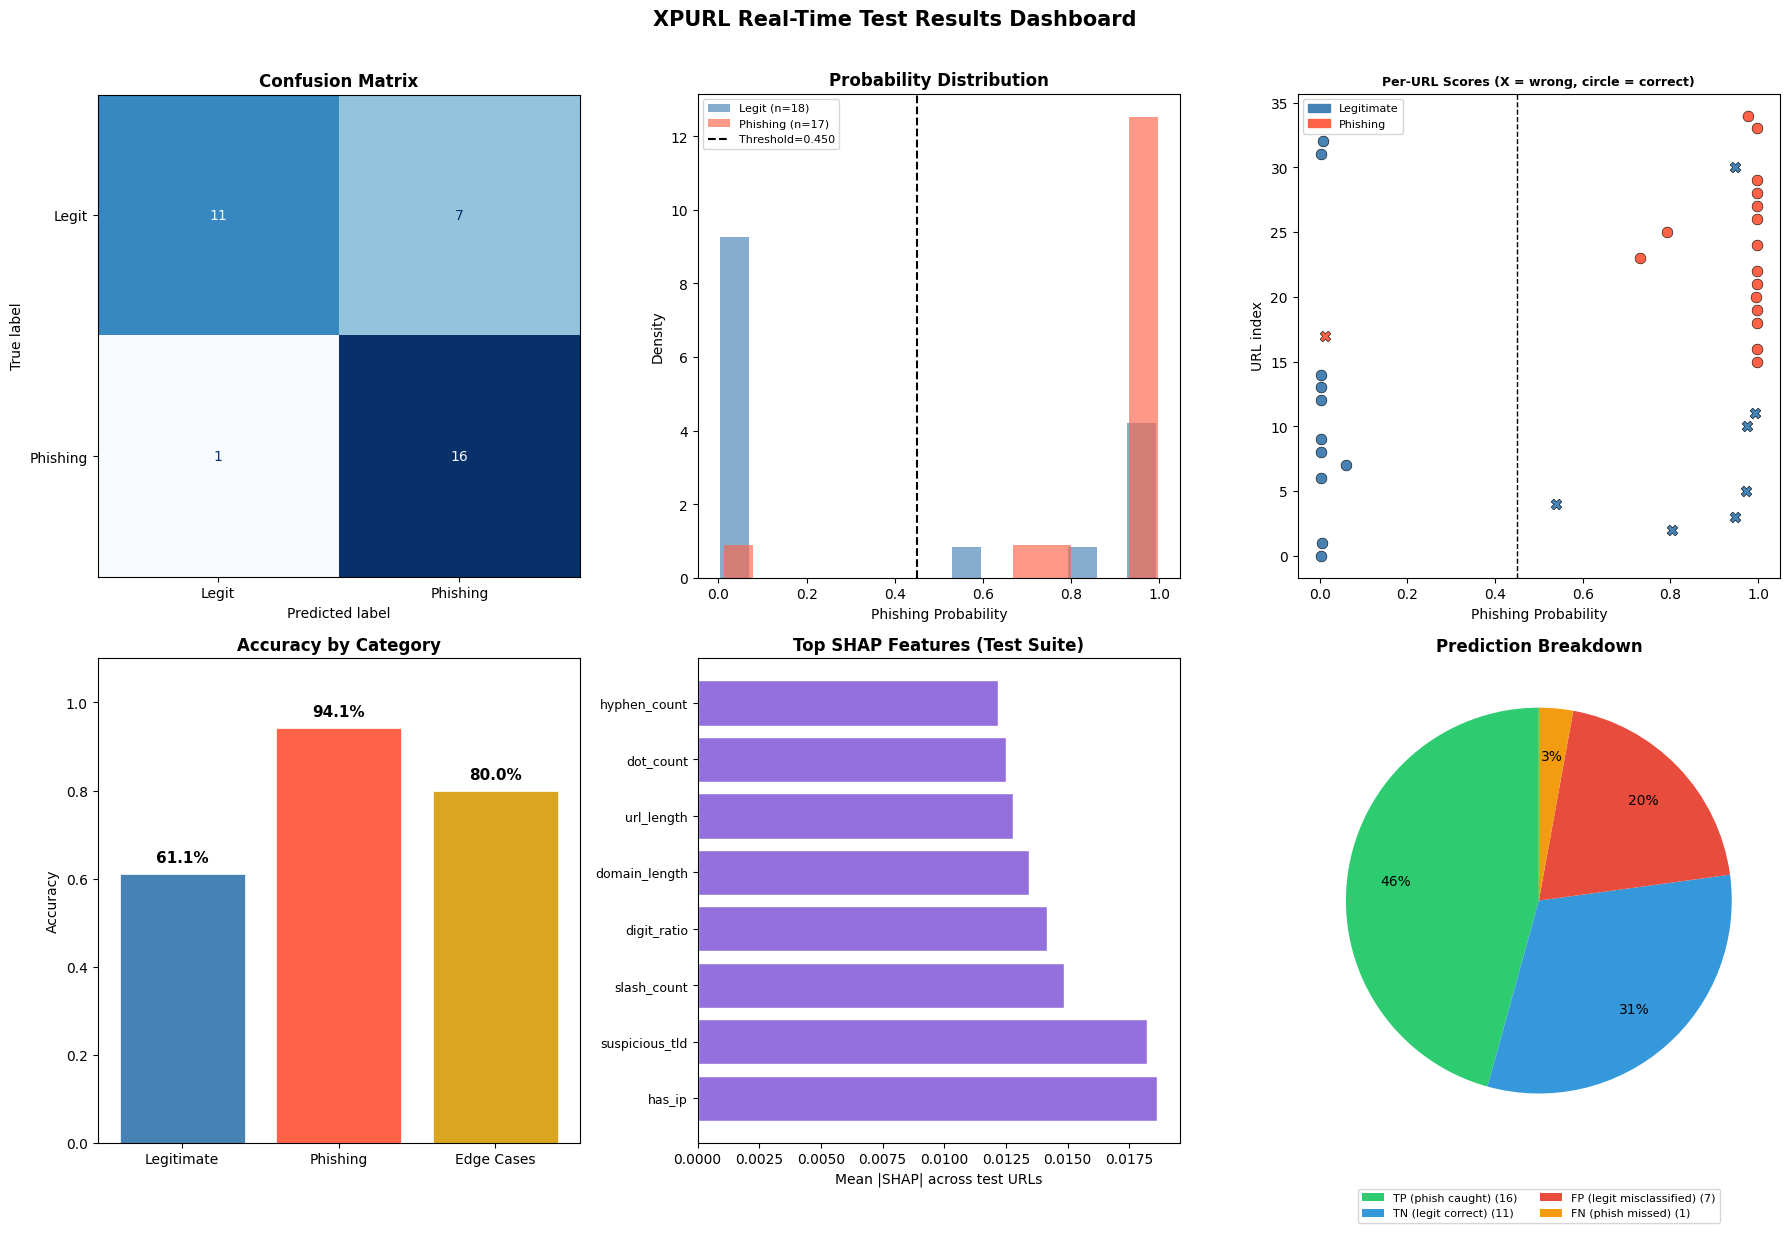

Dashboard saved to realtime_test_dashboard.png


In [49]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('XPURL Real-Time Test Results Dashboard', fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: Confusion Matrix ──────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
cm  = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Legit','Phishing']).plot(
    ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix', fontweight='bold')

# ── Plot 2: Probability distributions ────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
legit_probs = [r['prob'] for r in results if r['true'] == 0]
phish_probs = [r['prob'] for r in results if r['true'] == 1]
ax2.hist(legit_probs, bins=15, alpha=0.65, color='steelblue',
         label=f'Legit (n={len(legit_probs)})', density=True)
ax2.hist(phish_probs, bins=15, alpha=0.65, color='tomato',
         label=f'Phishing (n={len(phish_probs)})', density=True)
ax2.axvline(best_thresh, color='black', linestyle='--',
            linewidth=1.5, label=f'Threshold={best_thresh:.3f}')
ax2.set_xlabel('Phishing Probability'); ax2.set_ylabel('Density')
ax2.set_title('Probability Distribution', fontweight='bold')
ax2.legend(fontsize=8)

# ── Plot 3: Per-URL probability strip chart ───────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
for i, r in enumerate(results):
    color  = 'tomato' if r['true'] == 1 else 'steelblue'
    marker = 'X' if not r['correct'] else 'o'
    ax3.scatter(r['prob'], i, c=color, marker=marker,
                s=60, zorder=3, edgecolors='black', linewidths=0.4)
ax3.axvline(best_thresh, color='black', linestyle='--', linewidth=1)
ax3.set_xlabel('Phishing Probability')
ax3.set_ylabel('URL index')
ax3.set_title('Per-URL Scores (X = wrong, circle = correct)', fontweight='bold', fontsize=9)
ax3.set_xlim([-0.05, 1.05])
blue_p  = mpatches.Patch(color='steelblue', label='Legitimate')
red_p   = mpatches.Patch(color='tomato',    label='Phishing')
ax3.legend(handles=[blue_p, red_p], fontsize=8)

# ── Plot 4: Category accuracy bar ────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
cats  = ['Legitimate', 'Phishing', 'Edge Cases']
accs  = [legit_acc, phish_acc, edge_acc]
bcolors = ['steelblue', 'tomato', 'goldenrod']
bars = ax4.bar(cats, accs, color=bcolors, edgecolor='white', linewidth=0.5)
ax4.set_ylim([0, 1.1])
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy by Category', fontweight='bold')
for bar, v in zip(bars, accs):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{v:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ── Plot 5: Top global SHAP features across all test URLs ─────────────────
ax5 = fig.add_subplot(2, 3, 5)
all_shap_abs = defaultdict(list)
for r in results:
    for feat, val in r['top3']:
        all_shap_abs[feat].append(abs(val))
feat_means = {k: np.mean(v) for k, v in all_shap_abs.items()}
top_feats  = sorted(feat_means.items(), key=lambda x: x[1], reverse=True)[:8]
feat_names = [f[0] for f in top_feats]
feat_vals  = [f[1] for f in top_feats]
ax5.barh(range(len(feat_names)), feat_vals, color='mediumpurple', edgecolor='white')
ax5.set_yticks(range(len(feat_names)))
ax5.set_yticklabels(feat_names, fontsize=9)
ax5.set_xlabel('Mean |SHAP| across test URLs')
ax5.set_title('Top SHAP Features (Test Suite)', fontweight='bold')

# ── Plot 6: FP / FN breakdown ────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
n_tp = sum(1 for r in results if r['true']==1 and r['pred']==1)
n_tn = sum(1 for r in results if r['true']==0 and r['pred']==0)
n_fp = len(fp)
n_fn = len(fn)
labels_pie = ['TP (phish caught)', 'TN (legit correct)', 'FP (legit misclassified)', 'FN (phish missed)']
sizes_pie  = [n_tp, n_tn, n_fp, n_fn]
colors_pie = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
wedges, texts, autotexts = ax6.pie(
    sizes_pie, labels=None, colors=colors_pie, autopct='%1.0f%%',
    startangle=90, pctdistance=0.75
)
ax6.legend(wedges, [f'{l} ({s})' for l,s in zip(labels_pie,sizes_pie)],
           loc='lower center', bbox_to_anchor=(0.5,-0.18), fontsize=8, ncol=2)
ax6.set_title('Prediction Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig('realtime_test_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to realtime_test_dashboard.png')

## Stage 26 — Detailed Comparison Table (sortable DataFrame)

In [50]:
import pandas as pd

df_results = pd.DataFrame([{
    'URL'            : r['url'][:65] + ('...' if len(r['url'])>65 else ''),
    'True Label'     : 'Phishing' if r['true']==1 else 'Legitimate',
    'Prediction'     : 'Phishing' if r['pred']==1 else 'Legitimate',
    'Phish Prob'     : round(r['prob'], 4),
    'Correct'        : 'YES' if r['correct'] else 'NO',
    'Top SHAP Feature': r['top3'][0][0] if r['top3'] else 'N/A',
    'SHAP Value'     : round(r['top3'][0][1], 4) if r['top3'] else 0,
    'Source'         : r['source'],
    'Time (s)'       : round(r['elapsed'], 2)
} for r in results])

# Highlight wrong predictions in red
def highlight_wrong(row):
    color = 'background-color: #ffcccc' if row['Correct'] == 'NO' else ''
    return [color] * len(row)

print('Full results table (wrong predictions highlighted in red):')
display(df_results.style.apply(highlight_wrong, axis=1)
                        .set_properties(**{'font-size': '11px'}))

# Save CSV
df_results.to_csv('/content/realtime_test_results.csv', index=False)
print('\nSaved to /content/realtime_test_results.csv')

# Print only wrong predictions for quick review
wrong = df_results[df_results['Correct'] == 'NO']
if len(wrong) > 0:
    print(f'\n{len(wrong)} misclassified URLs:')
    for _, row in wrong.iterrows():
        print(f'  [{row["True Label"].upper():<12}] predicted {row["Prediction"].upper():<12}'
              f' prob={row["Phish Prob"]:.3f}  {row["URL"]}')
else:
    print('\nAll URLs classified correctly!')

Full results table (wrong predictions highlighted in red):


,URL,True Label,Prediction,Phish Prob,Correct,Top SHAP Feature,SHAP Value,Source,Time (s)
0,https://www.google.com,Legitimate,Legitimate,0.002500,YES,slash_count,0.012500,Alexa top-1M,0.090000
1,https://www.amazon.com/dp/B08N5WRWNW,Legitimate,Legitimate,0.006400,YES,entropy_path,-0.015800,Alexa top-1M,0.090000
2,https://github.com/openai/gpt-4,Legitimate,Phishing,0.804700,NO,domain_length,0.022000,Alexa top-1M,0.100000
3,https://stackoverflow.com/questions/tagged/python,Legitimate,Phishing,0.948300,NO,slash_count,-0.015800,Alexa top-1M,0.100000
4,https://docs.python.org/3/library/urllib.html,Legitimate,Phishing,0.538300,NO,entropy_path,-0.028700,Python docs,0.100000
5,https://pytorch.org/docs/stable/torch.html,Legitimate,Phishing,0.973500,NO,slash_count,-0.021000,PyTorch docs,0.090000
6,https://www.wikipedia.org/wiki/Machine_learning,Legitimate,Legitimate,0.002700,YES,slash_count,-0.017400,Wikipedia,0.090000
7,https://www.youtube.com/watch?v=dQw4w9WgXcQ,Legitimate,Legitimate,0.059600,YES,entropy_full,0.007300,Alexa top-1M,0.090000
8,https://www.linkedin.com/in/profile,Legitimate,Legitimate,0.002600,YES,slash_count,-0.017300,Alexa top-1M,0.100000
9,https://www.reddit.com/r/MachineLearning,Legitimate,Legitimate,0.002600,YES,slash_count,-0.015800,Alexa top-1M,0.090000



Saved to /content/realtime_test_results.csv

8 misclassified URLs:
  [LEGITIMATE  ] predicted PHISHING     prob=0.805  https://github.com/openai/gpt-4
  [LEGITIMATE  ] predicted PHISHING     prob=0.948  https://stackoverflow.com/questions/tagged/python
  [LEGITIMATE  ] predicted PHISHING     prob=0.538  https://docs.python.org/3/library/urllib.html
  [LEGITIMATE  ] predicted PHISHING     prob=0.974  https://pytorch.org/docs/stable/torch.html
  [LEGITIMATE  ] predicted PHISHING     prob=0.976  https://huggingface.co/distilbert-base-uncased
  [LEGITIMATE  ] predicted PHISHING     prob=0.992  https://arxiv.org/abs/2305.10403
  [PHISHING    ] predicted LEGITIMATE   prob=0.012  https://apple.com.account-verify.xyz/suspended/reactivate
  [LEGITIMATE  ] predicted PHISHING     prob=0.948  https://security.google.com/settings/security/activity


## Stage 27 — Add Your Own URLs (interactive)

In [52]:
# ── Test any URL you want ──────────────────────────────────────────────────
# Edit the list below and re-run this cell

MY_URLS = [
    'https://www.example.com',
    # Add more URLs here:
    # 'http://suspicious-url.xyz/login',
    # 'https://your-bank.com/account',
]

print('='*70)
print('CUSTOM URL TEST')
print('='*70)

while url != 'exit':
    url = input('Enter url:')
    pred, prob, top3 = predict_single(url)
    label = 'PHISHING' if pred == 1 else 'LEGITIMATE'
    risk  = 'HIGH' if prob > 0.8 else ('MEDIUM' if prob > 0.5 else 'LOW')

    print(f'URL        : {url}')
    print(f'Prediction : {label}')
    print(f'Phish Prob : {prob:.4f}  |  Risk: {risk}  |  Threshold: {best_thresh:.3f}')

    bar     = int(prob * 40)
    bar_str = '[' + '#'*bar + '.'*(40-bar) + ']'
    print(f'Probability: {bar_str} {prob:.1%}')

    if top3:
        print('Top SHAP drivers:')
        for feat, val in top3:
            direction = 'pushes toward phishing' if val > 0 else 'pushes toward legitimate'
            print(f'  {feat:30s}  {val:+.4f}  ({direction})')

    # Feature breakdown
    feats = extract_features(url)
    feat_dict = dict(zip(FEATURE_NAMES_ARR, feats))
    flagged = {k: v for k, v in feat_dict.items() if v > 0 and k in {
        'has_ip','brand_impersonation','suspicious_tld','has_punycode','phish_keywords'
    }}
    if flagged:
        print(f'Flagged heuristics: {list(flagged.keys())}')
    print('-'*70)

CUSTOM URL TEST
Enter url:http://rbxarmy.com


  0%|          | 0/1 [00:00<?, ?it/s]

URL        : http://rbxarmy.com
Prediction : PHISHING
Phish Prob : 0.9973  |  Risk: HIGH  |  Threshold: 0.450
Probability: [#######################################.] 99.7%
Top SHAP drivers:
  path_depth                      +0.0152  (pushes toward phishing)
  entropy_path                    +0.0054  (pushes toward phishing)
  subdomain_depth                 +0.0041  (pushes toward phishing)
----------------------------------------------------------------------
Enter url:	http://rizvedevelop.com/


  0%|          | 0/1 [00:00<?, ?it/s]

URL        : 	http://rizvedevelop.com/
Prediction : PHISHING
Phish Prob : 0.9948  |  Risk: HIGH  |  Threshold: 0.450
Probability: [#######################################.] 99.5%
Top SHAP drivers:
  slash_count                     -0.0043  (pushes toward legitimate)
  suspicious_tld                  +0.0042  (pushes toward phishing)
  entropy_path                    +0.0040  (pushes toward phishing)
----------------------------------------------------------------------
Enter url:https://alt.sikayetvar.com/superbet/guncel


...

URL        : https://alt.sikayetvar.com/superbet/guncel
Prediction : LEGITIMATE
Phish Prob : 0.0246  |  Risk: LOW  |  Threshold: 0.450
Probability: [........................................] 2.5%
Top SHAP drivers:
  slash_count                     -0.0147  (pushes toward legitimate)
  entropy_full                    +0.0077  (pushes toward phishing)
  query_length                    -0.0031  (pushes toward legitimate)
----------------------------------------------------------------------
Enter url:https://www,google.com


  0%|          | 0/1 [00:00<?, ?it/s]

URL        : https://www,google.com
Prediction : LEGITIMATE
Phish Prob : 0.0029  |  Risk: LOW  |  Threshold: 0.450
Probability: [........................................] 0.3%
Top SHAP drivers:
  complexity_score                -0.0107  (pushes toward legitimate)
  slash_count                     +0.0103  (pushes toward phishing)
  domain_length                   +0.0103  (pushes toward phishing)
----------------------------------------------------------------------
Enter url:exit


  0%|          | 0/1 [00:00<?, ?it/s]

URL        : exit
Prediction : PHISHING
Phish Prob : 0.9968  |  Risk: HIGH  |  Threshold: 0.450
Probability: [#######################################.] 99.7%
Top SHAP drivers:
  entropy_full                    -0.0211  (pushes toward legitimate)
  slash_count                     +0.0175  (pushes toward phishing)
  complexity_score                -0.0165  (pushes toward legitimate)
----------------------------------------------------------------------


## Stage 28 — Batch Test from CSV File

In [53]:
# ── Batch test from a CSV file ─────────────────────────────────────────────
# CSV must have columns: 'url' and optionally 'label' (0=legit, 1=phish)
# Upload your CSV to Colab and set the path below.

import os

CSV_PATH = '/content/urls_to_test.csv'   # <- change this path

if not os.path.exists(CSV_PATH):
    # Create a demo CSV if file doesn't exist
    demo_df = pd.DataFrame({
        'url': [
            'https://www.google.com',
            'http://paypal-secure.ru/verify?token=123',
            'https://github.com',
            'http://amazon-suspended.tk/login',
        ],
        'label': [0, 1, 0, 1]
    })
    demo_df.to_csv(CSV_PATH, index=False)
    print(f'Demo CSV created at {CSV_PATH}')

df_batch = pd.read_csv(CSV_PATH)
has_labels = 'label' in df_batch.columns
print(f'Loaded {len(df_batch)} URLs from CSV  |  Labels available: {has_labels}')

batch_results = []
for i, row in df_batch.iterrows():
    url = str(row['url']).strip()
    pred, prob, top3 = predict_single(url)
    entry = {
        'url'   : url,
        'pred'  : pred,
        'prob'  : prob,
        'risk'  : 'HIGH' if prob>0.8 else ('MEDIUM' if prob>0.5 else 'LOW'),
        'label' : 'Phishing' if pred==1 else 'Legitimate',
        'top_feat': top3[0][0] if top3 else 'N/A',
    }
    if has_labels:
        entry['true_label'] = int(row['label'])
        entry['correct']    = int(pred == int(row['label']))
    batch_results.append(entry)
    print(f'  [{i+1:3d}] {"PHISH" if pred==1 else "LEGIT":5s}  prob={prob:.3f}  {url[:60]}')

df_batch_out = pd.DataFrame(batch_results)
out_path = CSV_PATH.replace('.csv', '_predictions.csv')
df_batch_out.to_csv(out_path, index=False)
print(f'\nPredictions saved to {out_path}')

if has_labels:
    bt = [r['true_label'] for r in batch_results]
    bp = [r['pred']       for r in batch_results]
    print(f'Batch accuracy : {accuracy_score(bt, bp):.4f}')
    print(f'Batch F1       : {f1_score(bt, bp, zero_division=0):.4f}')

# Summary counts
n_phish = sum(1 for r in batch_results if r['pred']==1)
n_legit = sum(1 for r in batch_results if r['pred']==0)
n_high  = sum(1 for r in batch_results if r['risk']=='HIGH')
print(f'\nSummary: {n_phish} phishing  |  {n_legit} legitimate  |  {n_high} high-risk')

Demo CSV created at /content/urls_to_test.csv
Loaded 4 URLs from CSV  |  Labels available: True


  0%|          | 0/1 [00:00<?, ?it/s]

  [  1] LEGIT  prob=0.003  https://www.google.com


  0%|          | 0/1 [00:00<?, ?it/s]

  [  2] PHISH  prob=0.997  http://paypal-secure.ru/verify?token=123


  0%|          | 0/1 [00:00<?, ?it/s]

  [  3] LEGIT  prob=0.021  https://github.com


  0%|          | 0/1 [00:00<?, ?it/s]

  [  4] PHISH  prob=0.997  http://amazon-suspended.tk/login

Predictions saved to /content/urls_to_test_predictions.csv
Batch accuracy : 1.0000
Batch F1       : 1.0000

Summary: 2 phishing  |  2 legitimate  |  2 high-risk


In [54]:
# ── Stage 29: Dataset Extraction ─────────────────────────────────────────
# All variables (df_all, df_capped, idx_train, idx_val, idx_drift,
# stat_features_capped, stat_features_scaled, FEATURE_NAMES) are already
# in memory from training — no rebuild needed.

import os, json as _json, shutil
import numpy as np
import pandas as pd

OUT_DIR = '/content/xpurl_dataset_export'
os.makedirs(OUT_DIR, exist_ok=True)

print('='*60)
print('XPURL — Dataset Extraction')
print('='*60)

# ── 1. Full collected dataset (before cap) ────────────────────────────────
print('\n[1/8] Full dataset (before cap)...')
df_full_export = df_all[['url','label']].copy()
df_full_export['label_name'] = df_full_export['label'].map({0:'Legitimate', 1:'Phishing'})
df_full_export['url_length'] = df_full_export['url'].str.len()
df_full_export.to_csv(f'{OUT_DIR}/xpurl_dataset_full.csv', index=False)
print(f'  {len(df_full_export):,} URLs  |  '
      f'Legit: {(df_full_export["label"]==0).sum():,}  '
      f'Phishing: {(df_full_export["label"]==1).sum():,}')

# ── 2. Capped dataset with split column ──────────────────────────────────
print('\n[2/8] Capped dataset with split labels...')
df_cap_export = df_capped[['url','label']].copy()
df_cap_export['label_name'] = df_cap_export['label'].map({0:'Legitimate', 1:'Phishing'})
split_col = pd.Series('', index=range(len(df_capped)))
split_col.iloc[idx_train] = 'train'
split_col.iloc[idx_val]   = 'val'
split_col.iloc[idx_drift] = 'drift'
df_cap_export['split'] = split_col.values
df_cap_export.to_csv(f'{OUT_DIR}/xpurl_dataset_capped.csv', index=False)
print(f'  {len(df_cap_export):,} URLs  |  '
      f'Train: {len(idx_train):,}  Val: {len(idx_val):,}  Drift: {len(idx_drift):,}')

# ── 3. Individual split CSVs ─────────────────────────────────────────────
print('\n[3/8] Individual split files...')
for split_name, idx_list in [('train', idx_train), ('val', idx_val), ('drift', idx_drift)]:
    df_s = df_capped[['url','label']].iloc[idx_list].copy().reset_index(drop=True)
    df_s['label_name'] = df_s['label'].map({0:'Legitimate', 1:'Phishing'})
    df_s.to_csv(f'{OUT_DIR}/xpurl_dataset_{split_name}.csv', index=False)
    print(f'  {split_name:6s}: {len(df_s):,}  '
          f'Legit: {(df_s["label"]==0).sum():,}  '
          f'Phishing: {(df_s["label"]==1).sum():,}')

# ── 4. Feature matrix — raw (train only) ─────────────────────────────────
print('\n[4/8] Feature matrix (raw, train split)...')
df_feat_raw = pd.DataFrame(stat_features_capped[idx_train], columns=FEATURE_NAMES)
df_feat_raw.insert(0, 'label', df_capped['label'].iloc[idx_train].values)
df_feat_raw.insert(0, 'url',   df_capped['url'].iloc[idx_train].values)
df_feat_raw.to_csv(f'{OUT_DIR}/xpurl_features_train.csv', index=False)
print(f'  {len(df_feat_raw):,} rows × {len(df_feat_raw.columns)} cols (url + label + 25 features)')

# ── 5. Feature matrix — scaled (train only) ──────────────────────────────
print('\n[5/8] Feature matrix (StandardScaler scaled, train split)...')
df_feat_sc = pd.DataFrame(
    stat_features_scaled[idx_train],
    columns=[f'{n}_scaled' for n in FEATURE_NAMES]
)
df_feat_sc.insert(0, 'label', df_capped['label'].iloc[idx_train].values)
df_feat_sc.insert(0, 'url',   df_capped['url'].iloc[idx_train].values)
df_feat_sc.to_csv(f'{OUT_DIR}/xpurl_features_train_scaled.csv', index=False)
print(f'  {len(df_feat_sc):,} rows × {len(df_feat_sc.columns)} cols')

# ── 6. Feature matrix — all splits ───────────────────────────────────────
print('\n[6/8] Feature matrix (all splits)...')
df_feat_all = pd.DataFrame(stat_features_capped, columns=FEATURE_NAMES)
df_feat_all.insert(0, 'split', split_col.values)
df_feat_all.insert(0, 'label', df_capped['label'].values)
df_feat_all.insert(0, 'url',   df_capped['url'].values)
df_feat_all.to_csv(f'{OUT_DIR}/xpurl_features_all.csv', index=False)
print(f'  {len(df_feat_all):,} rows × {len(df_feat_all.columns)} cols')

# ── 7. Dataset statistics JSON ────────────────────────────────────────────
print('\n[7/8] Dataset statistics JSON...')

def split_stats(df):
    lengths = df['url'].str.len()
    return {
        'count'        : int(len(df)),
        'n_legitimate' : int((df['label']==0).sum()),
        'n_phishing'   : int((df['label']==1).sum()),
        'pct_phishing' : round(float((df['label']==1).mean()*100), 2),
        'avg_url_len'  : round(float(lengths.mean()), 1),
        'min_url_len'  : int(lengths.min()),
        'max_url_len'  : int(lengths.max()),
    }

dataset_meta = {
    'paper'          : 'XPURL: Explainable and Continually Adaptive Phishing URL Detection '
                       'via Hybrid Semantic-Statistical Encoding',
    'feature_names'  : FEATURE_NAMES,
    'n_features'     : len(FEATURE_NAMES),
    'sources'        : [
        'ISCX-URL-2016 (phishing only — benign excluded: simple domain strings)',
        'PhishTank verified phishing feed',
        'Realistic synthetic (benign with paths/queries + phishing patterns)',
    ],
    'preprocessing'  : {
        'scaler'        : 'StandardScaler (fit on train split only)',
        'cap_strategy'  : 'Stratified 50/50 (10,000 per class, dedup-limited)',
        'split_ratios'  : '70% train / 15% val / 15% drift',
        'max_char_len'  : CFG['max_char_len'],
        'tokenizer'     : 'distilbert-base-uncased (char-level spacing)',
    },
    'splits' : {
        'full'   : split_stats(df_all),
        'capped' : split_stats(df_capped),
        'train'  : split_stats(df_capped.iloc[idx_train]),
        'val'    : split_stats(df_capped.iloc[idx_val]),
        'drift'  : split_stats(df_capped.iloc[idx_drift]),
    },
    'feature_descriptions' : {
        'url_length'           : 'Total character length of URL',
        'domain_length'        : 'Length of netloc/hostname part',
        'dot_count'            : 'Number of dots in URL',
        'hyphen_count'         : 'Number of hyphens in URL',
        'underscore_count'     : 'Number of underscores in URL',
        'slash_count'          : 'Number of forward slashes',
        'query_mark'           : 'Presence of ? (query string)',
        'equals_count'         : 'Number of = signs in URL',
        'at_count'             : 'Number of @ symbols',
        'percent_count'        : 'Number of % (percent-encoded chars)',
        'digit_ratio'          : 'Fraction of digits in URL',
        'uppercase_ratio'      : 'Fraction of uppercase letters',
        'entropy_full'         : 'Shannon entropy of full URL string',
        'entropy_domain'       : 'Shannon entropy of domain name',
        'entropy_path'         : 'Shannon entropy of URL path',
        'subdomain_depth'      : 'Number of subdomain levels',
        'path_depth'           : 'Number of path segments',
        'query_length'         : 'Length of query string',
        'has_ip'               : '1 if IP address in hostname, else 0',
        'brand_impersonation'  : '1 if brand keyword + suspicious TLD, else 0',
        'suspicious_char_ratio': 'Ratio of chars in set @#%~|\\^`<>',
        'suspicious_tld'       : '1 if TLD in .ru/.tk/.xyz etc., else 0',
        'has_punycode'         : '1 if IDN punycode (xn--) present, else 0',
        'phish_keywords'       : '1 if login/verify/secure/account/signin in URL',
        'complexity_score'     : '(dots+hyphens+slashes+%-count+entropy) / 10',
    },
    'model_metrics' : {
        'val_f1'         : metrics_ewc_val['f1'],
        'val_auc'        : metrics_ewc_val['auc'],
        'val_aps'        : metrics_ewc_val['aps'],
        'bwt'            : float(BWT),
        'fwt'            : float(FWT),
        'shap_coherence' : float(cs_mean),
        'threshold'      : float(best_thresh),
    }
}

with open(f'{OUT_DIR}/xpurl_dataset_stats.json', 'w') as f:
    _json.dump(dataset_meta, f, indent=2)
print(f'  Saved: xpurl_dataset_stats.json')

# ── 8. Zip everything ─────────────────────────────────────────────────────
print('\n[8/8] Zipping...')
shutil.make_archive('/content/xpurl_datasets', 'zip', OUT_DIR)
zip_mb = os.path.getsize('/content/xpurl_datasets.zip') / 1024 / 1024
print(f'  /content/xpurl_datasets.zip  ({zip_mb:.1f} MB)')

# ── Summary table ─────────────────────────────────────────────────────────
print('\n' + '='*60)
print('FILES SAVED  →  /content/xpurl_dataset_export/')
print('='*60)
for fn in sorted(os.listdir(OUT_DIR)):
    kb = os.path.getsize(f'{OUT_DIR}/{fn}') / 1024
    rows = ''
    if fn.endswith('.csv'):
        with open(f'{OUT_DIR}/{fn}') as f:
            rows = f'  ({sum(1 for _ in f)-1:,} rows)'
    print(f'  {fn:<42}  {kb:7.1f} KB{rows}')
print('='*60)
print('Download xpurl_datasets.zip from the Files panel (left sidebar).')


XPURL — Dataset Extraction

[1/8] Full dataset (before cap)...
  197,823 URLs  |  Legit: 112,271  Phishing: 85,552

[2/8] Capped dataset with split labels...
  20,000 URLs  |  Train: 14,000  Val: 3,000  Drift: 3,000

[3/8] Individual split files...
  train : 14,000  Legit: 7,005  Phishing: 6,995
  val   : 3,000  Legit: 1,482  Phishing: 1,518
  drift : 3,000  Legit: 1,513  Phishing: 1,487

[4/8] Feature matrix (raw, train split)...
  14,000 rows × 27 cols (url + label + 25 features)

[5/8] Feature matrix (StandardScaler scaled, train split)...
  14,000 rows × 27 cols

[6/8] Feature matrix (all splits)...
  20,000 rows × 28 cols

[7/8] Dataset statistics JSON...
  Saved: xpurl_dataset_stats.json

[8/8] Zipping...
  /content/xpurl_datasets.zip  (5.9 MB)

FILES SAVED  →  /content/xpurl_dataset_export/
  xpurl_dataset_capped.csv                     1196.1 KB  (20,000 rows)
  xpurl_dataset_drift.csv                       162.9 KB  (3,000 rows)
  xpurl_dataset_full.csv                      11

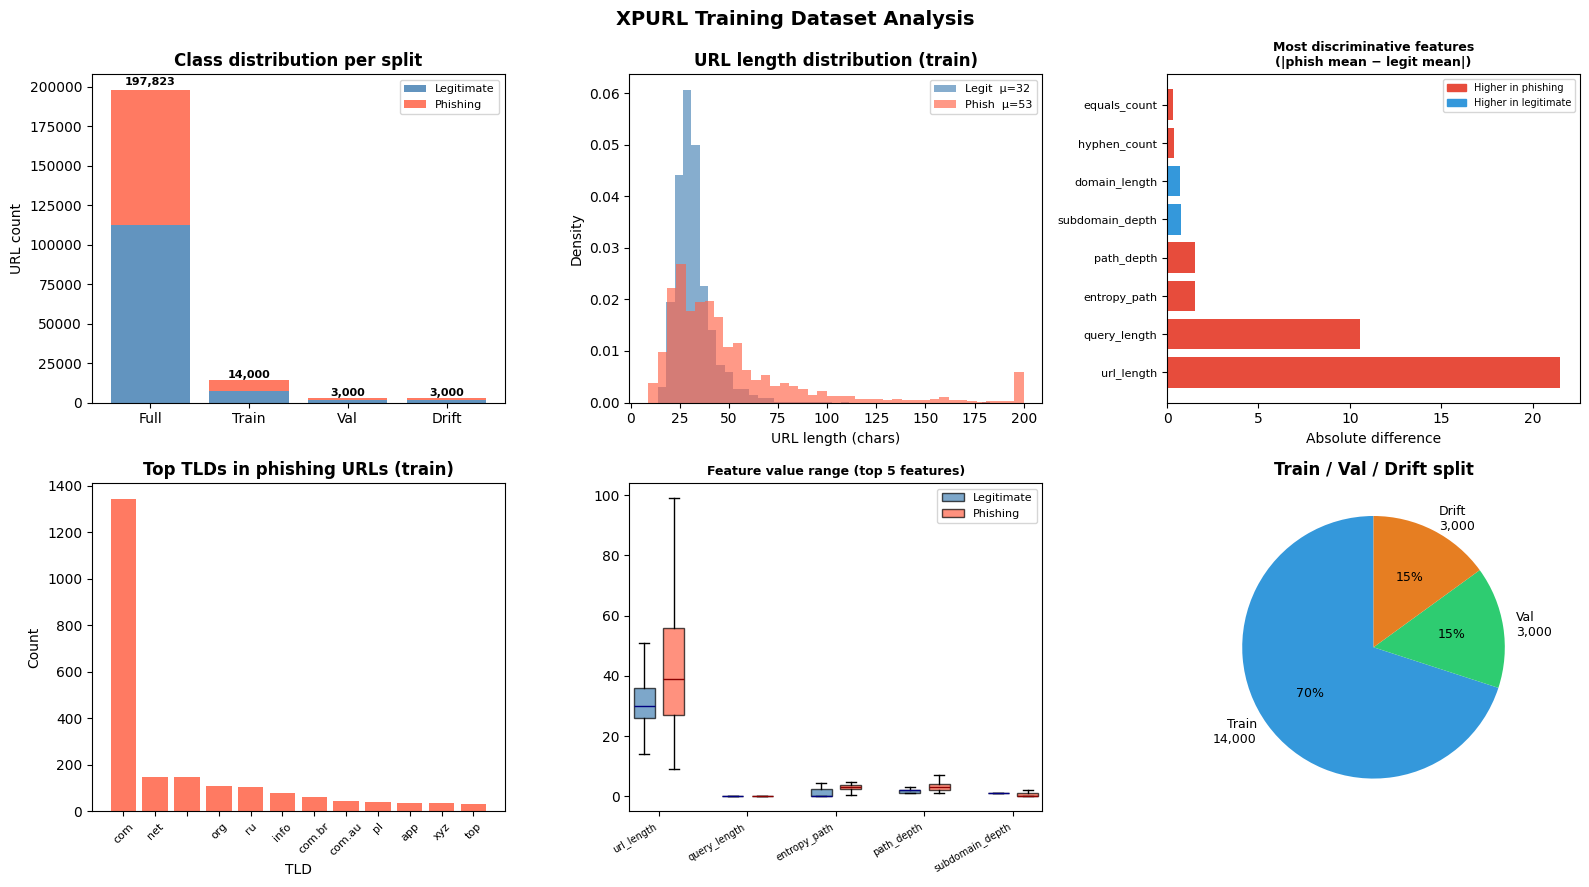

✅ Analysis chart saved to xpurl_dataset_export/xpurl_dataset_analysis.png

Key facts for paper write-up:
  Total collected URLs : 197,823
  Used for training    : 20,000 (after stratified cap)
  Train / Val / Drift  : 14,000 / 3,000 / 3,000
  Phishing ratio (cap) : 50.0% train  |  50.6% val
  Features             : 25 statistical + char-level DistilBERT
  Most discriminative  : url_length (Δ=21.521), query_length (Δ=10.537)


In [55]:
# ── Stage 30: Dataset Analysis Plots ─────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUT_DIR = '/content/xpurl_dataset_export'

df_tr = pd.read_csv(f'{OUT_DIR}/xpurl_dataset_train.csv')
df_vl = pd.read_csv(f'{OUT_DIR}/xpurl_dataset_val.csv')
df_dr = pd.read_csv(f'{OUT_DIR}/xpurl_dataset_drift.csv')
df_fu = pd.read_csv(f'{OUT_DIR}/xpurl_dataset_full.csv')
df_ft = pd.read_csv(f'{OUT_DIR}/xpurl_features_train.csv')

feat_cols = [c for c in df_ft.columns if c not in ['url','label']]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('XPURL Training Dataset Analysis', fontsize=14, fontweight='bold')

# ── Plot 1: Class distribution per split ─────────────────────────────────
ax = axes[0, 0]
splits = ['Full', 'Train', 'Val', 'Drift']
dfs    = [df_fu, df_tr, df_vl, df_dr]
legit  = [(d['label']==0).sum() for d in dfs]
phish  = [(d['label']==1).sum() for d in dfs]
x = range(4)
ax.bar(x, legit, color='steelblue', label='Legitimate', alpha=0.85)
ax.bar(x, phish, bottom=legit, color='tomato', label='Phishing', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_title('Class distribution per split', fontweight='bold')
ax.set_ylabel('URL count'); ax.legend(fontsize=8)
for i, (l, p) in enumerate(zip(legit, phish)):
    total = l + p
    ax.text(i, total + total*0.01, f'{total:,}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Plot 2: URL length distribution ─────────────────────────────────────
ax = axes[0, 1]
ll = df_tr[df_tr['label']==0]['url'].str.len()
pl = df_tr[df_tr['label']==1]['url'].str.len()
ax.hist(ll.clip(0, 200), bins=40, alpha=0.65, color='steelblue',
        label=f'Legit  μ={ll.mean():.0f}', density=True)
ax.hist(pl.clip(0, 200), bins=40, alpha=0.65, color='tomato',
        label=f'Phish  μ={pl.mean():.0f}', density=True)
ax.set_title('URL length distribution (train)', fontweight='bold')
ax.set_xlabel('URL length (chars)'); ax.set_ylabel('Density'); ax.legend(fontsize=8)

# ── Plot 3: Top discriminative features ──────────────────────────────────
ax = axes[0, 2]
legit_mean = df_ft[df_ft['label']==0][feat_cols].mean()
phish_mean = df_ft[df_ft['label']==1][feat_cols].mean()
diff = (phish_mean - legit_mean).abs().sort_values(ascending=False)[:8]
colors_bar = ['#e74c3c' if phish_mean[f] > legit_mean[f] else '#3498db'
              for f in diff.index]
ax.barh(diff.index, diff.values, color=colors_bar)
ax.set_title('Most discriminative features\n(|phish mean − legit mean|)',
             fontweight='bold', fontsize=9)
ax.set_xlabel('Absolute difference'); ax.tick_params(axis='y', labelsize=8)
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Higher in phishing'),
    mpatches.Patch(color='#3498db', label='Higher in legitimate'),
], fontsize=7)

# ── Plot 4: TLD distribution in phishing ─────────────────────────────────
ax = axes[1, 0]
tlds = [tldextract.extract(u).suffix
        for u in df_tr[df_tr['label']==1]['url'].sample(
            min(3000, len(df_tr)), random_state=42)]
tld_counts = pd.Series(tlds).value_counts().head(12)
ax.bar(tld_counts.index, tld_counts.values, color='tomato', alpha=0.85)
ax.set_title('Top TLDs in phishing URLs (train)', fontweight='bold')
ax.set_xlabel('TLD'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45, labelsize=8)

# ── Plot 5: Feature value boxplot (top 5 features) ───────────────────────
ax = axes[1, 1]
top5 = diff.index[:5].tolist()
data_legit = [df_ft[df_ft['label']==0][f].clip(0, df_ft[f].quantile(0.99)).values
              for f in top5]
data_phish = [df_ft[df_ft['label']==1][f].clip(0, df_ft[f].quantile(0.99)).values
              for f in top5]
positions_l = [i*3 + 0.7 for i in range(5)]
positions_p = [i*3 + 1.7 for i in range(5)]
bp1 = ax.boxplot(data_legit, positions=positions_l, widths=0.7,
                 patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.7),
                 medianprops=dict(color='navy'),
                 showfliers=False)
bp2 = ax.boxplot(data_phish, positions=positions_p, widths=0.7,
                 patch_artist=True,
                 boxprops=dict(facecolor='tomato', alpha=0.7),
                 medianprops=dict(color='darkred'),
                 showfliers=False)
ax.set_xticks([i*3 + 1.2 for i in range(5)])
ax.set_xticklabels(top5, rotation=30, ha='right', fontsize=7)
ax.set_title('Feature value range (top 5 features)', fontweight='bold', fontsize=9)
ax.legend([bp1['boxes'][0], bp2['boxes'][0]],
          ['Legitimate', 'Phishing'], fontsize=8)

# ── Plot 6: Train/Val/Drift split sizes ──────────────────────────────────
ax = axes[1, 2]
sizes = [len(df_tr), len(df_vl), len(df_dr)]
labels_pie = [f'Train\n{len(df_tr):,}', f'Val\n{len(df_vl):,}', f'Drift\n{len(df_dr):,}']
wedges, texts, pcts = ax.pie(
    sizes, labels=labels_pie,
    colors=['#3498db', '#2ecc71', '#e67e22'],
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 9}
)
ax.set_title('Train / Val / Drift split', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/xpurl_dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Analysis chart saved to xpurl_dataset_export/xpurl_dataset_analysis.png')

# ── Print key dataset facts for the paper ────────────────────────────────
print('\nKey facts for paper write-up:')
print(f'  Total collected URLs : {len(df_fu):,}')
print(f'  Used for training    : {len(df_tr)+len(df_vl)+len(df_dr):,} (after stratified cap)')
print(f'  Train / Val / Drift  : {len(df_tr):,} / {len(df_vl):,} / {len(df_dr):,}')
print(f'  Phishing ratio (cap) : {(df_tr["label"]==1).mean():.1%} train  |  '
      f'{(df_vl["label"]==1).mean():.1%} val')
print(f'  Features             : {len(feat_cols)} statistical + char-level DistilBERT')
print(f'  Most discriminative  : {diff.index[0]} (Δ={diff.values[0]:.3f}), '
      f'{diff.index[1]} (Δ={diff.values[1]:.3f})')
